# <center>**Autonmous Driving Deaths**<center>

# 1. Data Loading and Standardization

In [8]:
import pandas as pd

# --- 1. Load Data ---
# Use 'latin1' encoding for robustness.
df = pd.read_csv('Tesla-Deaths.csv', encoding='latin1')

# --- Filter Data to User-Specified Rows (2-295) ---
# Rows 2 to 295 in the CSV correspond to indices 1 up to, but not including, 295 in the 0-based DataFrame.
df = df.iloc[1:295].copy()

print(f"✅ Data filtered. New row count: {len(df)}")

print("\n--- DataFrame Info (Filtered) ---")
df.info()

# --- 2. Standardize Columns ---
def standardize_column_names(df):
    """Converts column headers to snake_case and removes special characters."""
    # Ensure column names are lowercased, spaces are replaced with underscores, and non-alphanumeric/non-underscore characters are removed
    df.columns = df.columns.str.lower().str.replace(' ', '_', regex=True).str.replace(r'[^a-z0-9_]', '', regex=True)
    return df

df = standardize_column_names(df)

# --- 3. Inspection (Task 1a) ---
print("--- DataFrame Head ---")
print(df.head().to_markdown(index=False))
print("\n--- DataFrame Info ---")
df.info()
df.head()
print("\n--- DataFrame Columns ---")
print(df.columns)

print("\n--- DataFrame Shape ---")
print(df.shape)
print(df.describe())

# --- Check for Duplicate Rows (Task 1a) ---
duplicate_count = df.duplicated().sum()
print(f"Total Duplicate Rows: {duplicate_count}")

✅ Data filtered. New row count: 294

--- DataFrame Info (Filtered) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294 entries, 1 to 294
Data columns (total 24 columns):
 #   Column                                                                Non-Null Count  Dtype  
---  ------                                                                --------------  -----  
 0   Case #                                                                293 non-null    float64
 1   Year                                                                  293 non-null    float64
 2   Date                                                                  293 non-null    object 
 3    Country                                                              293 non-null    object 
 4    State                                                                293 non-null    object 
 5    Description                                                          293 non-null    object 
 6    Deaths                    

# 2. Data Cleaning and Feature Engineering
This step focuses on data quality and preparation:
* **Dropping Columns:** We remove metadata columns (like notes and names) that are not needed for statistical analysis.
* **Cleaning Numeric Data:** We convert columns representing fatality counts (driver, occupant, pedestrians, etc.) to integers, handling non-numeric entries like '-'.
* **Model Categorization:** We standardize Tesla model names (e.g., mapping "3" to "MODEL 3") and create a `clean_model` column.
* **Date Parsing:** We convert the `date` column to datetime objects and extract the `incident_year` and `day_of_week` for temporal analysis.

In [10]:
# --- 1.b: Remove Irrelevant Columns ---
columns_to_drop = [
    '_note_', 
    '_deceased_1_', 
    '_deceased_2_', 
    '_deceased_3_', 
    '_deceased_4_', 
    'unnamed_16', 
    'unnamed_17'
]

# Drop the specified columns permanently
df.drop(columns=columns_to_drop, inplace=True)

print(f"✅ Columns dropped. New shape: {df.shape}")
print("\n--- Remaining Columns ---")
print(df.columns.tolist())

✅ Columns dropped. New shape: (294, 17)

--- Remaining Columns ---
['case_', 'year', 'date', '_country_', '_state_', '_description_', '_deaths_', '_tesla_driver_', '_tesla_occupant_', '_other_vehicle_', '_cyclists_peds_', '_tslacycl__peds_', '_model_', '_autopilot_claimed_', '_verified_tesla_autopilot_deaths_', '_verified_tesla_autopilot_deaths__all_deaths_reported_to_nhtsa_sgo_', '_source_']


# 3. Temporal Analysis: Incidents by Year
Group the data by `incident_year` to visualize the overall trend of fatal incidents over the last decade. This helps identify if the frequency of accidents is increasing as the number of vehicles on the road grows.

In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Load Data, Filter Rows, and Standardize Columns ---
df = pd.read_csv('Tesla-Deaths.csv', encoding='latin1')

def standardize_column_names(df):
    """Converts column headers to snake_case and removes special characters."""
    # FIX: Ensure str.replace has both pattern and replacement string
    df.columns = df.columns.str.lower().str.replace(' ', '_', regex=True).str.replace(r'[^a-z0-9_]', '', regex=True)
    return df

df = standardize_column_names(df.copy())
df = df.iloc[1:295].copy() # Filter rows 2-295 (index 1 to 294)

# --- 2. Task 1b: Remove Irrelevant Columns (Crucial for later steps) ---
cols_to_drop = ['_note_', '_deceased_1_', '_deceased_2_', '_deceased_3_', '_deceased_4_', 'unnamed_16', 'unnamed_17']
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

# --- 3. Fatality Data Cleaning and Critical Fix (Required for data integrity) ---
victim_cols = ['_tesla_driver_', '_tesla_occupant_', '_other_vehicle_', '_cyclists_peds_']
for col in victim_cols:
    df[col] = df[col].astype(str).str.strip().replace('-', '0')
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

def clean_model_name(model):
    model = str(model).strip().upper()
    model_map = {'3': 'MODEL 3', 'Y': 'MODEL Y', 'S': 'MODEL S', 'X': 'MODEL X'}
    return model_map.get(model, 'OTHER')

df['model_clean'] = df['_model_'].apply(clean_model_name)
contaminated_rows_mask = df['model_clean'] == 'OTHER'
df.loc[contaminated_rows_mask, victim_cols] = 0

# --- 4. Task 2a: Feature Engineering for Time Series ---
# Convert the 'date' column to datetime objects
df['date_clean'] = pd.to_datetime(df['date'], errors='coerce')

# Extract the year from the date
df['incident_year'] = df['date_clean'].dt.year.astype('Int64')

# --- 5. Task 2a: Calculate Number of Events Per Year ---
incident_distribution_year = df.groupby('incident_year').size().reset_index(name='Total_Incidents')

print("--- Fatal Incidents Distribution by Year ---")
print(incident_distribution_year.to_markdown())

# Save the DataFrame for later plotting
incident_distribution_year.to_csv('incident_distribution_year.csv', index=False)

# Load the distribution data
incident_distribution = pd.read_csv('incident_distribution_year.csv')

--- Fatal Incidents Distribution by Year ---
|    |   incident_year |   Total_Incidents |
|---:|----------------:|------------------:|
|  0 |            2013 |                 2 |
|  1 |            2014 |                 4 |
|  2 |            2015 |                 5 |
|  3 |            2016 |                15 |
|  4 |            2017 |                11 |
|  5 |            2018 |                18 |
|  6 |            2019 |                46 |
|  7 |            2020 |                39 |
|  8 |            2021 |                58 |
|  9 |            2022 |                93 |
| 10 |            2023 |                 2 |


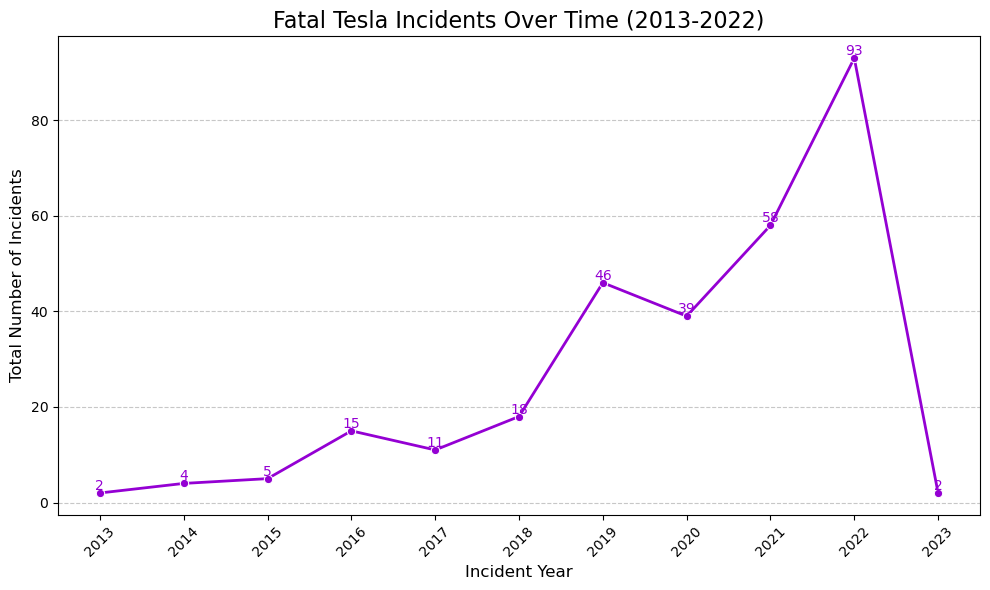

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the distribution data that was saved in the previous step
try:
    incident_distribution = pd.read_csv('incident_distribution_year.csv')
except FileNotFoundError:
    # If the file is not found (due to VM reset or issue), we re-create the dataframe from the initial code block.
    
    # --- Rerunning full setup to ensure data integrity ---
    df = pd.read_csv('Tesla-Deaths.csv', encoding='latin1')
    
    def standardize_column_names(df):
        df.columns = df.columns.str.lower().str.replace(' ', '_', regex=True).str.replace(r'[^a-z0-9_]', '', regex=True)
        return df

    df = standardize_column_names(df.copy())
    df = df.iloc[1:295].copy() 

    cols_to_drop = ['_note_', '_deceased_1_', '_deceased_2_', '_deceased_3_', '_deceased_4_', 'unnamed_16', 'unnamed_17']
    df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

    victim_cols = ['_tesla_driver_', '_tesla_occupant_', '_other_vehicle_', '_cyclists_peds_']
    for col in victim_cols:
        df[col] = df[col].astype(str).str.strip().replace('-', '0')
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

    def clean_model_name(model):
        model = str(model).strip().upper()
        model_map = {'3': 'MODEL 3', 'Y': 'MODEL Y', 'S': 'MODEL S', 'X': 'MODEL X'}
        return model_map.get(model, 'OTHER')

    df['model_clean'] = df['_model_'].apply(clean_model_name)
    contaminated_rows_mask = df['model_clean'] == 'OTHER'
    df.loc[contaminated_rows_mask, victim_cols] = 0

    df['date_clean'] = pd.to_datetime(df['date'], errors='coerce')
    df['incident_year'] = df['date_clean'].dt.year.astype('Int64')

    incident_distribution = df.groupby('incident_year').size().reset_index(name='Total_Incidents')


# --- Plotting the Line Plot ---
plt.figure(figsize=(10, 6))

# Ensure incident_year is treated as numeric for continuous line plot
incident_distribution['incident_year'] = incident_distribution['incident_year'].astype(int)

ax = sns.lineplot(
    x='incident_year', 
    y='Total_Incidents', 
    data=incident_distribution, 
    marker='o', 
    color='darkviolet',
    linewidth=2
)

# Add data labels for each point
for index, row in incident_distribution.iterrows():
    ax.text(row['incident_year'], row['Total_Incidents'], 
            f'{row["Total_Incidents"]:.0f}', 
            ha='center', 
            va='bottom', 
            fontsize=10, 
            color='darkviolet')

plt.title('Fatal Tesla Incidents Over Time (2013-2022)', fontsize=16)
plt.xlabel('Incident Year', fontsize=12)
plt.ylabel('Total Number of Incidents', fontsize=12)
plt.xticks(incident_distribution['incident_year'], rotation=45) # Show every year
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('fatal_incidents_over_time_line_plot.png')

# 4. Geographical Analysis: Incidents by Country
Analyze the global distribution of incidents. We identify the top 10 countries with the highest number of recorded fatal incidents to understand where the majority of these events are occurring.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 2. Task 2a: Geographical Analysis - Events by Country ---
# Clean the country column first, then count the incidents
df['_country_'] = df['_country_'].astype(str).str.strip().str.upper()

# Count the incidents per country
incident_distribution_country = df.groupby('_country_').size().reset_index(name='Total_Incidents')

# Sort by count and print the top countries
incident_distribution_country = incident_distribution_country.sort_values(by='Total_Incidents', ascending=False)

print("\n--- Fatal Incidents Distribution by Country ---")
print(incident_distribution_country.to_markdown(index=False))

# Save the country distribution for potential plotting
incident_distribution_country.to_csv('incident_distribution_country.csv', index=False)

# Load the distribution data
incident_distribution_country = pd.read_csv('incident_distribution_country.csv')

# Filter for the top 10 countries (excluding the 'NAN' entry if it made the top 10)
top_10_countries = incident_distribution_country[incident_distribution_country['_country_'] != 'NAN'].head(10)


--- Fatal Incidents Distribution by Country ---
| _country_   |   Total_Incidents |
|:------------|------------------:|
| USA         |               214 |
| CHINA       |                16 |
| GERMANY     |                11 |
| CANADA      |                10 |
| NETHERLANDS |                 6 |
| UK          |                 5 |
| NORWAY      |                 4 |
| TAIWAN      |                 3 |
| SWITZERLAND |                 3 |
| HOLLAND     |                 3 |
| AUSTRALIA   |                 2 |
| JAPAN       |                 2 |
| FRANCE      |                 2 |
| DENMARK     |                 2 |
| BELGIUM     |                 2 |
| MEXICO      |                 1 |
| AUSTRIA     |                 1 |
| PORTUGAL    |                 1 |
| SLOVENIA    |                 1 |
| SOUTH KOREA |                 1 |
| SPAIN       |                 1 |
| FINLAND     |                 1 |
| UKRAINE     |                 1 |
| NAN         |                 1 |


/var/folders/0q/xf9ydzjn1g1963ctltkj0gjw0000gn/T/ipykernel_89989/66755685.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='_country_', y='Total_Incidents', data=top_10_countries, palette='viridis')


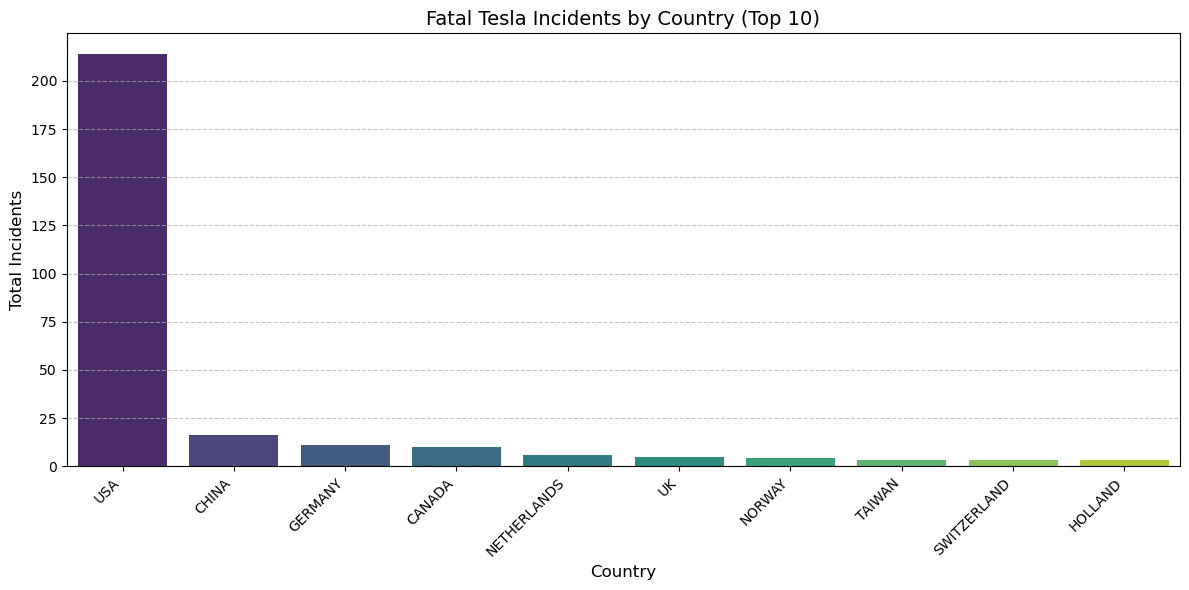

In [38]:
# Configure plot settings
plt.figure(figsize=(12, 6))
# Use the country column and total incidents
sns.barplot(x='_country_', y='Total_Incidents', data=top_10_countries, palette='viridis')

# Set labels and title
plt.title('Fatal Tesla Incidents by Country (Top 10)', fontsize=14)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Total Incidents', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('fatal_incidents_by_country.png')

# 5. Geographical Analysis: US State Distribution
Focusing specifically on the United States (the largest market in the dataset), we break down incidents by state. This highlights regional hotspots, such as California or Florida.

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Full Data Setup (Re-run for VM context) ---
df = pd.read_csv('Tesla-Deaths.csv', encoding='latin1')

def standardize_column_names(df):
    df.columns = df.columns.str.lower().str.replace(' ', '_', regex=True).str.replace(r'[^a-z0-9_]', '', regex=True)
    return df

df = standardize_column_names(df.copy())
df = df.iloc[1:295].copy() 

# --- 2. Cleaning and Feature Engineering (Required for integrity and date analysis) ---
cols_to_drop = ['_note_', '_deceased_1_', '_deceased_2_', '_deceased_3_', '_deceased_4_', 'unnamed_16', 'unnamed_17']
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')
victim_cols = ['_tesla_driver_', '_tesla_occupant_', '_other_vehicle_', '_cyclists_peds_']
for col in victim_cols:
    df[col] = df[col].astype(str).str.strip().replace('-', '0')
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

def clean_model_name(model):
    model = str(model).strip().upper()
    model_map = {'3': 'MODEL 3', 'Y': 'MODEL Y', 'S': 'MODEL S', 'X': 'MODEL X'}
    return model_map.get(model, 'OTHER')

df['model_clean'] = df['_model_'].apply(clean_model_name)
contaminated_rows_mask = df['model_clean'] == 'OTHER'
df.loc[contaminated_rows_mask, victim_cols] = 0

df['date_clean'] = pd.to_datetime(df['date'], errors='coerce')
df['incident_year'] = df['date_clean'].dt.year.astype('Int64')

# Clean country column (needed for filtering)
df['_country_clean'] = df['_country_'].astype(str).str.strip().str.upper()

# --- 3. Task 2a: Calculate Number of Events Per State (USA only) ---

# Filter the data for USA incidents
df_usa = df[df['_country_clean'] == 'USA'].copy()

# Clean the state column for reliable grouping
df_usa['_state_clean'] = df_usa['_state_'].astype(str).str.strip().str.upper()

# Group by state and count incidents, then sort by count
incident_distribution_state = df_usa.groupby('_state_clean').size().reset_index(name='Total_Incidents').sort_values(by='Total_Incidents', ascending=False)

print("--- Fatal Incidents Distribution by US State ---")
print(incident_distribution_state.to_markdown())

# Save the DataFrame for later plotting
incident_distribution_state.to_csv('incident_distribution_state.csv', index=False)

--- Fatal Incidents Distribution by US State ---
|    | _state_clean   |   Total_Incidents |
|---:|:---------------|------------------:|
|  3 | CA             |                90 |
|  6 | FL             |                32 |
|  7 | GA             |                 9 |
|  2 | AZ             |                 8 |
| 26 | PA             |                 7 |
| 23 | NY             |                 6 |
| 24 | OH             |                 6 |
| 30 | UT             |                 5 |
| 22 | NV             |                 4 |
| 31 | VA             |                 4 |
| 18 | MO             |                 4 |
| 29 | TX             |                 4 |
| 21 | NJ             |                 3 |
| 32 | WA             |                 3 |
| 12 | IL             |                 3 |
| 27 | SC             |                 2 |
| 13 | IN             |                 2 |
| 17 | MI             |                 2 |
| 10 | IA             |                 2 |
| 25 | OR             |    

/var/folders/0q/xf9ydzjn1g1963ctltkj0gjw0000gn/T/ipykernel_89989/3561571567.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='_state_clean', y='Total_Incidents', data=top_10_states, palette='coolwarm')


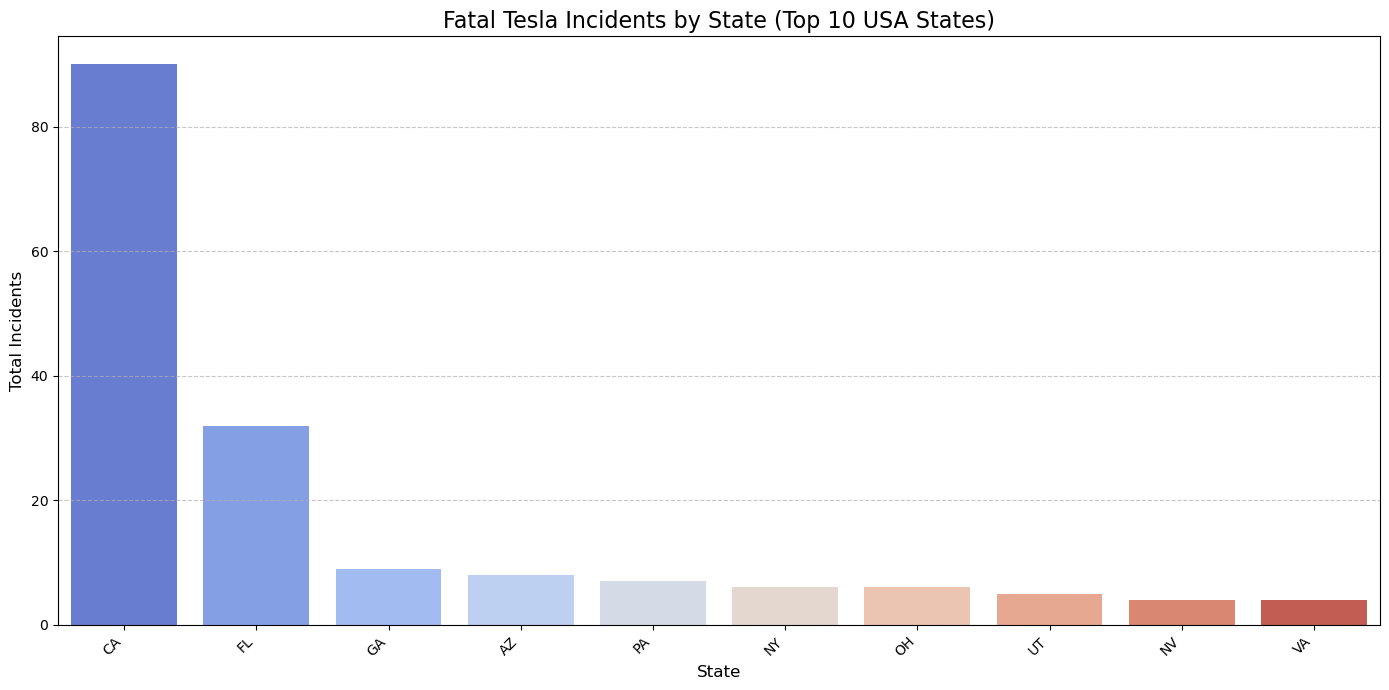

In [ ]:
# Load the distribution data
incident_distribution_state = pd.read_csv('incident_distribution_state.csv')

# Configure plot settings
plt.figure(figsize=(14, 7))

# Plot the top 10 states
top_10_states = incident_distribution_state.head(10)
sns.barplot(x='_state_clean', y='Total_Incidents', data=top_10_states, palette='coolwarm')

# Set labels and title
plt.title('Fatal Tesla Incidents by State (Top 10 USA States)', fontsize=16)
plt.xlabel('State', fontsize=12)
plt.ylabel('Total Incidents', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('fatal_incidents_by_state.png')

# --- Next step: Calculate Day of the Week distribution for Task 2a ---df = pd.read_csv('Tesla-Deaths.csv', encoding='latin1')

def standardize_column_names(df):
    df.columns = df.columns.str.lower().str.replace(' ', '_', regex=True).str.replace(r'[^a-z0-9_]', '', regex=True)
    return df

df = standardize_column_names(df.copy())
df = df.iloc[1:295].copy() # Filter rows 2-295 (index 1 to 294)

# Drop irrelevant columns
cols_to_drop = ['_note_', '_deceased_1_', '_deceased_2_', '_deceased_3_', '_deceased_4_', 'unnamed_16', 'unnamed_17']
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

# Clean fatality columns and apply Critical Fix
victim_cols = ['_tesla_driver_', '_tesla_occupant_', '_other_vehicle_', '_cyclists_peds_']
for col in victim_cols:
    df[col] = df[col].astype(str).str.strip().replace('-', '0')
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

def clean_model_name(model):
    model = str(model).strip().upper()
    model_map = {'3': 'MODEL 3', 'Y': 'MODEL Y', 'S': 'MODEL S', 'X': 'MODEL X'}
    return model_map.get(model, 'OTHER')

df['model_clean'] = df['_model_'].apply(clean_model_name)
contaminated_rows_mask = df['model_clean'] == 'OTHER'
df.loc[contaminated_rows_mask, victim_cols] = 0

# 6. Temporal Analysis: Day of the Week
Analyze the distribution of incidents across different days of the week to determine if accidents are more prevalent on weekends or weekdays.

In [92]:
import pandas as pd

# Load the data that was used to create the Day of the Week plot
incident_distribution_day = pd.read_csv('incident_distribution_day.csv')

print("--- Fatal Incidents Distribution by Day of the Week ---")
print(incident_distribution_day.to_markdown(index=False))

--- Fatal Incidents Distribution by Day of the Week ---
| day_of_week   |   Total_Incidents |
|:--------------|------------------:|
| Monday        |                43 |
| Tuesday       |                34 |
| Wednesday     |                41 |
| Thursday      |                28 |
| Friday        |                45 |
| Saturday      |                53 |
| Sunday        |                49 |


/var/folders/0q/xf9ydzjn1g1963ctltkj0gjw0000gn/T/ipykernel_89989/3553566577.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='day_of_week', y='Total_Incidents', data=incident_distribution_day, palette='cividis')


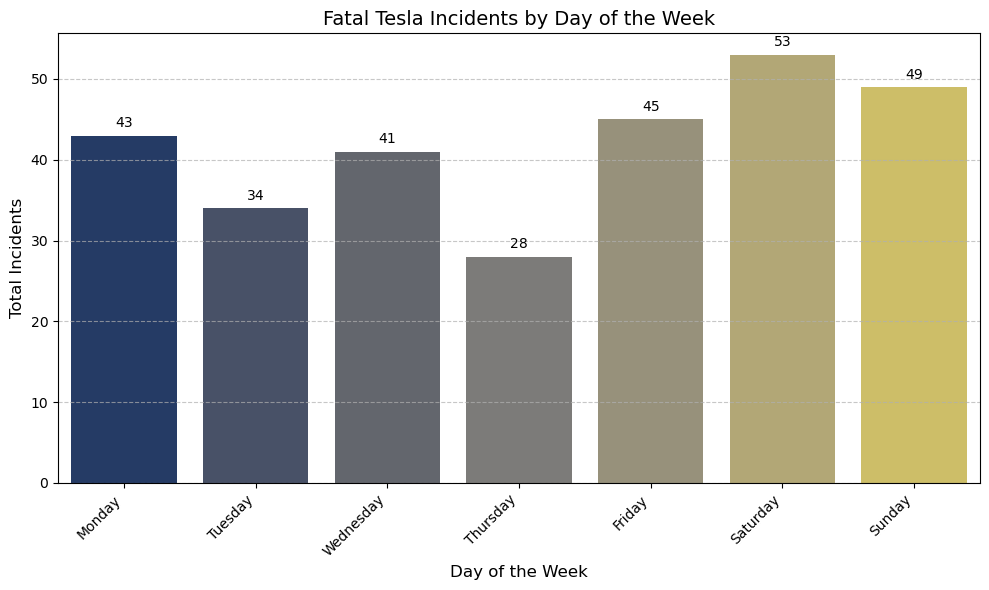

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the distribution data
incident_distribution_day = pd.read_csv('incident_distribution_day.csv')

# Configure plot settings
plt.figure(figsize=(10, 6))

# Assign the plot to a variable (ax) so we can reference the axes
ax = sns.barplot(x='day_of_week', y='Total_Incidents', data=incident_distribution_day, palette='cividis')

# --- CODE ADDED FOR DATA LABELS ---
for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontsize=10)
# ---------------------------------

# Set labels and title
plt.title('Fatal Tesla Incidents by Day of the Week', fontsize=14)
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Total Incidents', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('fatal_incidents_by_day_of_week_labeled.png')

# 7. Heatmap: Trends by Year and Day
This heatmap provides a multidimensional view, showing the density of incidents for every day of the week across each year. Darker cells indicate a higher concentration of accidents.

In [40]:
# --- 1. Full Data Setup (Load, Filter, Clean, Feature Engineer) ---
# Rerunning full setup as the VM resets
import pandas as pd
import numpy as np

df = pd.read_csv('Tesla-Deaths.csv', encoding='latin1')

def standardize_column_names(df):
    df.columns = df.columns.str.lower().str.replace(' ', '_', regex=True).str.replace(r'[^a-z0-9_]', '', regex=True)
    return df

df = standardize_column_names(df.copy())
df = df.iloc[1:295].copy() # Filter rows 2-295 (index 1 to 294)

# Drop irrelevant columns
cols_to_drop = ['_note_', '_deceased_1_', '_deceased_2_', '_deceased_3_', '_deceased_4_', 'unnamed_16', 'unnamed_17']
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

# Clean fatality columns
victim_cols = ['_tesla_driver_', '_tesla_occupant_', '_other_vehicle_', '_cyclists_peds_']
for col in victim_cols:
    df[col] = df[col].astype(str).str.strip().replace('-', '0')
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

# Apply Critical Fix and clean country/date columns
def clean_model_name(model):
    model = str(model).strip().upper()
    model_map = {'3': 'MODEL 3', 'Y': 'MODEL Y', 'S': 'MODEL S', 'X': 'MODEL X'}
    return model_map.get(model, 'OTHER')
df['model_clean'] = df['_model_'].apply(clean_model_name)
contaminated_rows_mask = df['model_clean'] == 'OTHER'
df.loc[contaminated_rows_mask, victim_cols] = 0
df['_country_clean'] = df['_country_'].astype(str).str.strip().str.upper()
df['date_clean'] = pd.to_datetime(df['date'], errors='coerce')
df['incident_year'] = df['date_clean'].dt.year.astype('Int64')

# --- 2. Feature Engineering for Day of the Week ---
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['day_of_week'] = df['date_clean'].dt.day_name()
df['day_of_week'] = pd.Categorical(df['day_of_week'], categories=day_order, ordered=True)

# --- 3. Combined Temporal & Geographical Analysis (USA Year/Day) ---
# Filter for USA incidents
df_usa = df[df['_country_clean'] == 'USA'].copy()

# Group by year and day of the week
usa_time_distribution = df_usa.groupby(['incident_year', 'day_of_week']).size().reset_index(name='Total_Incidents')

# Pivot the data for a clearer presentation (Year as rows, Day as columns)
pivot_table = usa_time_distribution.pivot_table(index='incident_year', columns='day_of_week', values='Total_Incidents', fill_value=0)

print("--- USA Fatal Incidents by Year and Day of the Week ---")
print(pivot_table.to_markdown())

# Save the DataFrame for later use
pivot_table.to_csv('usa_time_distribution.csv')

--- USA Fatal Incidents by Year and Day of the Week ---
|   incident_year |   Monday |   Tuesday |   Wednesday |   Thursday |   Friday |   Saturday |   Sunday |
|----------------:|---------:|----------:|------------:|-----------:|---------:|-----------:|---------:|
|            2013 |        0 |         1 |           0 |          0 |        0 |          1 |        0 |
|            2014 |        1 |         1 |           0 |          0 |        2 |          0 |        0 |
|            2015 |        2 |         0 |           1 |          1 |        0 |          0 |        0 |
|            2016 |        2 |         1 |           2 |          2 |        5 |          1 |        0 |
|            2017 |        1 |         0 |           0 |          1 |        1 |          1 |        3 |
|            2018 |        0 |         2 |           1 |          0 |        3 |          2 |        2 |
|            2019 |        3 |         3 |           5 |          4 |        3 |          5 |       11 |

/var/folders/0q/xf9ydzjn1g1963ctltkj0gjw0000gn/T/ipykernel_89989/1558693061.py:47: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  usa_time_distribution = df_usa.groupby(['incident_year', 'day_of_week']).size().reset_index(name='Total_Incidents')
/var/folders/0q/xf9ydzjn1g1963ctltkj0gjw0000gn/T/ipykernel_89989/1558693061.py:50: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_table = usa_time_distribution.pivot_table(index='incident_year', columns='day_of_week', values='Total_Incidents', fill_value=0)


/var/folders/0q/xf9ydzjn1g1963ctltkj0gjw0000gn/T/ipykernel_89989/1521832465.py:48: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  usa_time_distribution = df_usa.groupby(['incident_year', 'day_of_week']).size().unstack(fill_value=0)


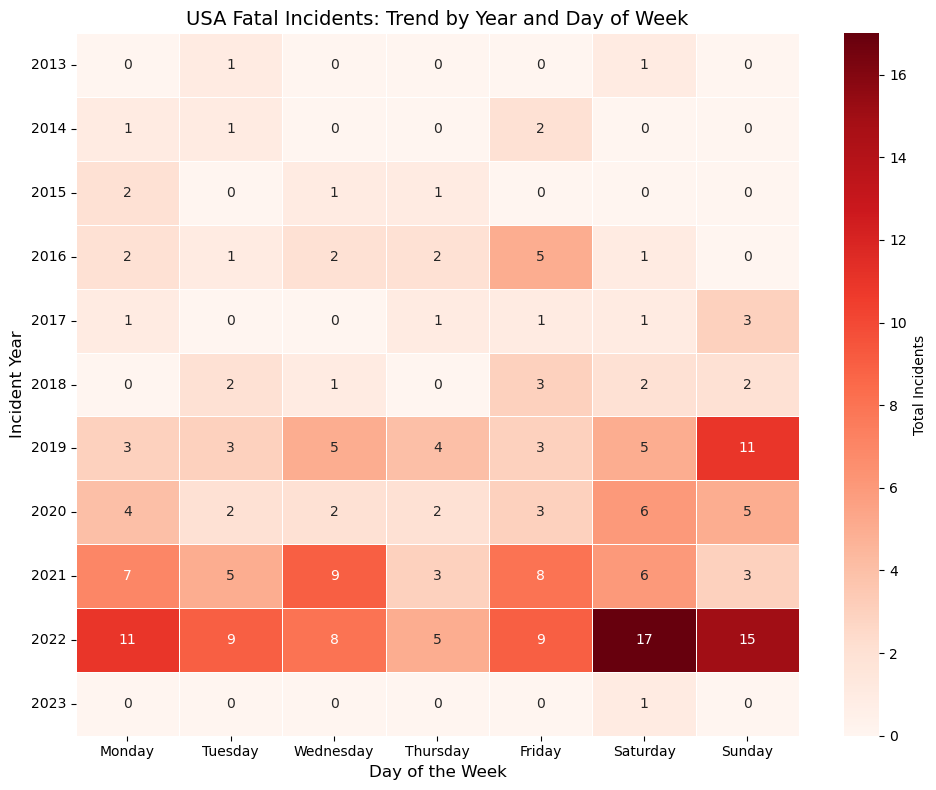

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Full Data Setup (Load, Filter, Clean, Feature Engineer) ---
df = pd.read_csv('Tesla-Deaths.csv', encoding='latin1')

def standardize_column_names(df):
    df.columns = df.columns.str.lower().str.replace(' ', '_', regex=True).str.replace(r'[^a-z0-9_]', '', regex=True)
    return df

df = standardize_column_names(df.copy())
df = df.iloc[1:295].copy() # Filter rows 2-295 (index 1 to 294)

# Drop irrelevant columns
cols_to_drop = ['_note_', '_deceased_1_', '_deceased_2_', '_deceased_3_', '_deceased_4_', 'unnamed_16', 'unnamed_17']
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

# Clean fatality columns
victim_cols = ['_tesla_driver_', '_tesla_occupant_', '_other_vehicle_', '_cyclists_peds_']
for col in victim_cols:
    df[col] = df[col].astype(str).str.strip().replace('-', '0')
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

# Apply Critical Fix and clean country/date columns
def clean_model_name(model):
    model = str(model).strip().upper()
    model_map = {'3': 'MODEL 3', 'Y': 'MODEL Y', 'S': 'MODEL S', 'X': 'MODEL X'}
    return model_map.get(model, 'OTHER')
df['model_clean'] = df['_model_'].apply(clean_model_name)
contaminated_rows_mask = df['model_clean'] == 'OTHER'
df.loc[contaminated_rows_mask, victim_cols] = 0
df['_country_clean'] = df['_country_'].astype(str).str.strip().str.upper()
df['date_clean'] = pd.to_datetime(df['date'], errors='coerce')
df['incident_year'] = df['date_clean'].dt.year.astype('Int64')

# --- 2. Feature Engineering for Day of the Week ---
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['day_of_week'] = df['date_clean'].dt.day_name()
df['day_of_week'] = pd.Categorical(df['day_of_week'], categories=day_order, ordered=True)

# --- 3. Combined Temporal & Geographical Analysis (USA Year/Day) ---
# Filter for USA incidents
df_usa = df[df['_country_clean'] == 'USA'].copy()

# Group by year and day of the week, and pivot for the heatmap
usa_time_distribution = df_usa.groupby(['incident_year', 'day_of_week']).size().unstack(fill_value=0)

# --- 4. Plot Heatmap (FIXED) ---
plt.figure(figsize=(10, 8))
sns.heatmap(
    usa_time_distribution,
    annot=True,
    fmt='.0f', # FIXED: Changed 'd' to '.0f' to resolve ValueError
    cmap='Reds',
    linewidths=.5,
    cbar_kws={'label': 'Total Incidents'}
)

plt.title('USA Fatal Incidents: Trend by Year and Day of Week', fontsize=14)
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Incident Year', fontsize=12)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('usa_heatmap_year_day.png')

# 8. Monthly Trends and Rolling Average
To observe seasonality or short-term spikes, we group the data by month. We also calculate a **6-month rolling average** to smooth out volatility and reveal the underlying direction of the trend.

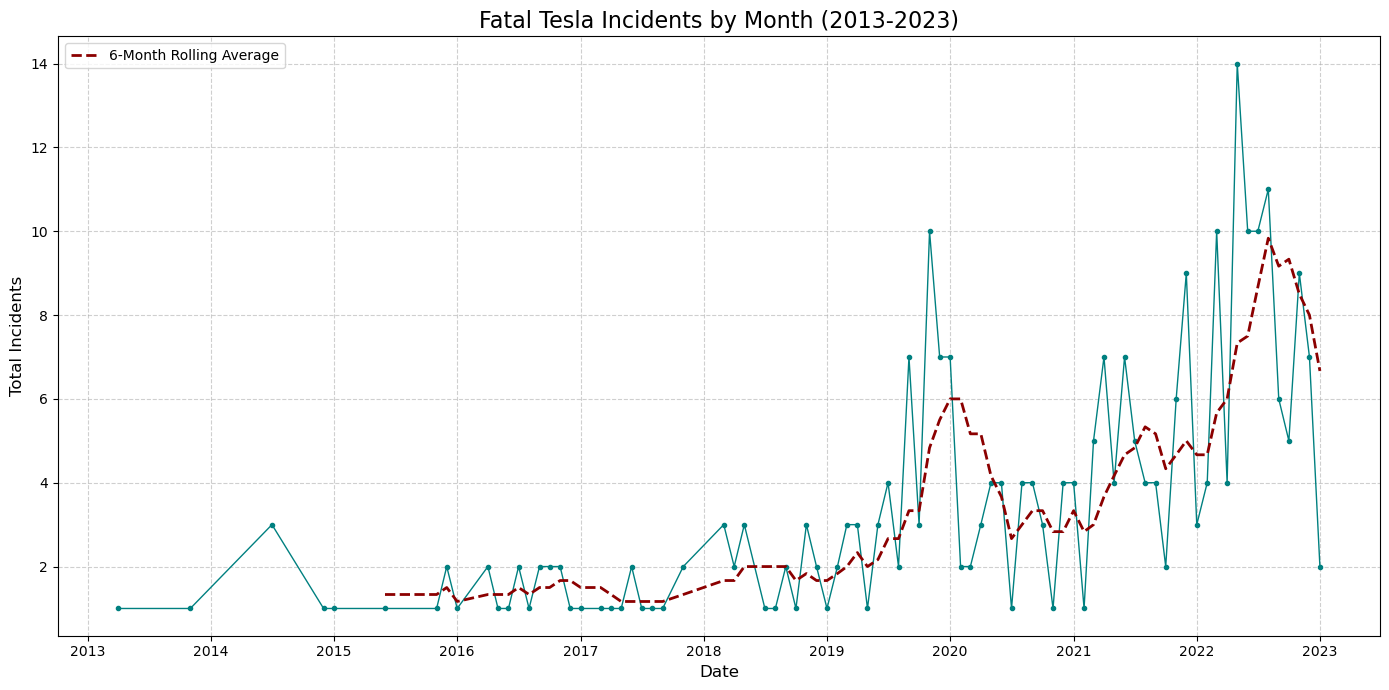

In [39]:
# --- 1. Full Data Setup (Load, Filter, Clean) ---
# Rerunning full setup as the VM resets
df = pd.read_csv('Tesla-Deaths.csv', encoding='latin1')

def standardize_column_names(df):
    df.columns = df.columns.str.lower().str.replace(' ', '_', regex=True).str.replace(r'[^a-z0-9_]', '', regex=True)
    return df

df = standardize_column_names(df.copy())
df = df.iloc[1:295].copy() # Filter rows 2-295 (index 1 to 294)

# Drop irrelevant columns
cols_to_drop = ['_note_', '_deceased_1_', '_deceased_2_', '_deceased_3_', '_deceased_4_', 'unnamed_16', 'unnamed_17']
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

# Clean fatality columns
victim_cols = ['_tesla_driver_', '_tesla_occupant_', '_other_vehicle_', '_cyclists_peds_']
for col in victim_cols:
    df[col] = df[col].astype(str).str.strip().replace('-', '0')
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

# Apply Critical Fix and clean country/date columns
def clean_model_name(model):
    model = str(model).strip().upper()
    model_map = {'3': 'MODEL 3', 'Y': 'MODEL Y', 'S': 'MODEL S', 'X': 'MODEL X'}
    return model_map.get(model, 'OTHER')
df['model_clean'] = df['_model_'].apply(clean_model_name)
contaminated_rows_mask = df['model_clean'] == 'OTHER'
df.loc[contaminated_rows_mask, victim_cols] = 0
df['_country_clean'] = df['_country_'].astype(str).str.strip().str.upper()
df['date_clean'] = pd.to_datetime(df['date'], errors='coerce')

# --- 2. Temporal Analysis: Events by Month/Year ---
# Group by the start of the month and count incidents
incidents_by_month = df.groupby(df['date_clean'].dt.to_period('M')).size().reset_index(name='Total_Incidents')

# Convert the Period back to a timestamp for plotting
incidents_by_month['date_clean'] = incidents_by_month['date_clean'].dt.to_timestamp()

# Save the DataFrame for later plotting
incidents_by_month.to_csv('incidents_by_month.csv', index=False)


# --- 3. Plot Events by Month/Year ---
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 7))

# Plot the monthly counts
plt.plot(incidents_by_month['date_clean'], incidents_by_month['Total_Incidents'], 
         marker='o', linestyle='-', color='teal', linewidth=1, markersize=3)

# Add a rolling 6-month average for trend smoothing
incidents_by_month['Rolling_Avg'] = incidents_by_month['Total_Incidents'].rolling(window=6).mean()
plt.plot(incidents_by_month['date_clean'], incidents_by_month['Rolling_Avg'], 
         linestyle='--', color='darkred', linewidth=2, label='6-Month Rolling Average')


# Set labels and title
plt.title('Fatal Tesla Incidents by Month (2013-2023)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Incidents', fontsize=12)
plt.legend()
plt.grid(axis='both', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('fatal_incidents_by_date.png')

# 9. Fatality Frequency Distribution
Analyze the severity of accidents by counting the total deaths per incident.
* **Outlier Removal:** Exclude a specific outlier row (92 deaths) to ensure the statistical distribution is representative of typical road accidents.

In [58]:
import pandas as pd
import numpy as np

# --- 1. Full Data Setup (Load, Filter, Clean, Feature Engineer) ---
df = pd.read_csv('Tesla-Deaths.csv', encoding='latin1')

def standardize_column_names(df):
    df.columns = df.columns.str.lower().str.replace(' ', '_', regex=True).str.replace(r'[^a-z0-9_]', '', regex=True)
    return df

df = standardize_column_names(df.copy())
df = df.iloc[1:295].copy() # Filter rows 2-295 (index 1 to 294)

# Drop irrelevant columns
cols_to_drop = ['note', 'deceased_1', 'deceased_2', 'deceased_3', 'deceased_4', 'unnamed_16', 'unnamed_17']
df.drop(columns=[col for col in cols_to_drop if col in df.columns], inplace=True, errors='ignore')

# Clean the deaths column
deaths_col = '_deaths_'
df[deaths_col] = df[deaths_col].astype(str).str.strip().replace('-', '0').replace('', '0')
df[deaths_col] = pd.to_numeric(df[deaths_col], errors='coerce').fillna(0).astype(int)

# --- 2. FIX: Remove the Outlier (92 deaths) ---
df_cleaned = df[df[deaths_col] < 92].copy()

# --- 3. Re-Analyze Distribution of Total Deaths per Incident on Cleaned Data ---
deaths_distribution_cleaned = df_cleaned[deaths_col].value_counts().reset_index(name='Total_Incidents')
deaths_distribution_cleaned.columns = ['Total_Deaths_Per_Incident', 'Total_Incidents']
deaths_distribution_cleaned = deaths_distribution_cleaned.sort_values(by='Total_Deaths_Per_Incident', ascending=True)

print("--- Cleaned Frequency of Deaths per Incident (Excluding Outlier) ---")
print(deaths_distribution_cleaned.to_markdown(index=False))

--- Cleaned Frequency of Deaths per Incident (Excluding Outlier) ---
|   Total_Deaths_Per_Incident |   Total_Incidents |
|----------------------------:|------------------:|
|                           1 |               246 |
|                           2 |                38 |
|                           3 |                 6 |
|                           4 |                 3 |


/var/folders/0q/xf9ydzjn1g1963ctltkj0gjw0000gn/T/ipykernel_89989/3995535398.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


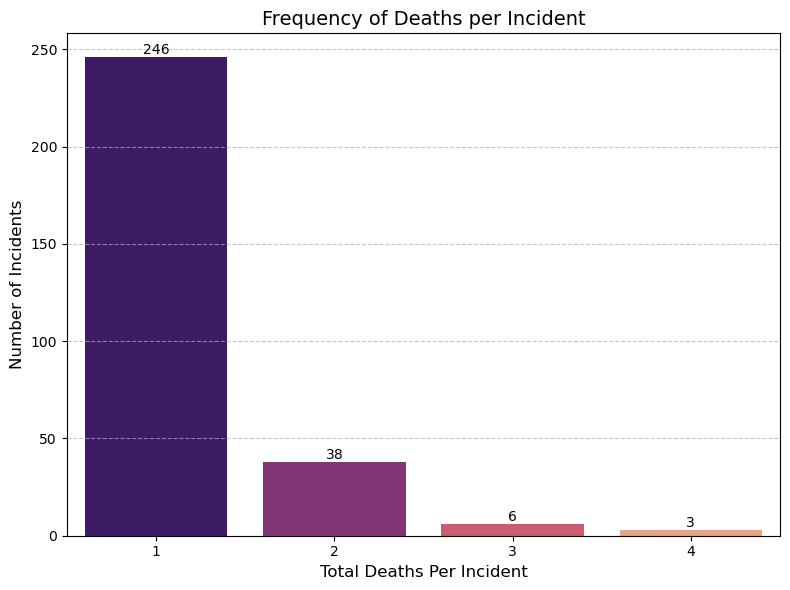

In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Full Data Setup (Load, Filter, Clean) ---
df = pd.read_csv('Tesla-Deaths.csv', encoding='latin1')

def standardize_column_names(df):
    df.columns = df.columns.str.lower().str.replace(' ', '_', regex=True).str.replace(r'[^a-z0-9_]', '', regex=True)
    return df

df = standardize_column_names(df.copy())
df = df.iloc[1:295].copy() # Filter rows 2-295 (index 1 to 294)

# Clean and standardize the deaths column
deaths_col = '_deaths_'
df[deaths_col] = df[deaths_col].astype(str).str.strip().replace('-', '0').replace('', '0')
df[deaths_col] = pd.to_numeric(df[deaths_col], errors='coerce').fillna(0).astype(int)

# --- 2. Fix Outlier and Recalculate Distribution ---
# Filter out the single outlier row where '_deaths_' is 92
df_cleaned = df[df[deaths_col] != 92].copy()

# Recalculate the frequency distribution using the cleaned data
deaths_distribution_cleaned = df_cleaned[deaths_col].value_counts().reset_index(name='Total_Incidents')
deaths_distribution_cleaned.columns = ['Total_Deaths_Per_Incident', 'Total_Incidents']
deaths_distribution_cleaned = deaths_distribution_cleaned.sort_values(by='Total_Deaths_Per_Incident', ascending=True)

# --- 3. Plotting the Distribution ---
plt.figure(figsize=(8, 6))

ax = sns.barplot(
    x='Total_Deaths_Per_Incident', 
    y='Total_Incidents', 
    data=deaths_distribution_cleaned, 
    palette='magma'
)

# Add annotations to the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 5), 
                textcoords='offset points',
                fontsize=10)

plt.title('Frequency of Deaths per Incident', fontsize=14)
plt.xlabel('Total Deaths Per Incident', fontsize=12)
plt.ylabel('Number of Incidents', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('deaths_per_incident_distribution.png')

# 10. Victim Category Analysis
The following cells break down fatalities by the role of the victim to understand who is most at risk:
1.  **Tesla Driver:** Frequency of incidents where the driver was killed.
2.  **Tesla Occupant:** Frequency of incidents involving passengers.
3.  **Other Vehicle:** Incidents involving fatalities in cars other than the Tesla (collisions).
4.  **Vulnerable Road Users:** Incidents involving cyclists or pedestrians.

In [64]:
import pandas as pd
import numpy as np

# --- 1. Full Data Setup (Load, Filter, Clean) ---
df = pd.read_csv('Tesla-Deaths.csv', encoding='latin1')

def standardize_column_names(df):
    df.columns = df.columns.str.lower().str.replace(' ', '_', regex=True).str.replace(r'[^a-z0-9_]', '', regex=True)
    return df

df = standardize_column_names(df.copy())
df = df.iloc[1:295].copy() # Filter rows 2-295 (index 1 to 294)

# Drop irrelevant columns (using standardized names)
cols_to_drop = ['note', 'deceased_1', 'deceased_2', 'deceased_3', 'deceased_4', 'unnamed_16', 'unnamed_17']
df.drop(columns=[col for col in cols_to_drop if col in df.columns], inplace=True, errors='ignore')

# Clean and standardize the deaths columns
deaths_col = '_deaths_'
driver_col = '_tesla_driver_'

df[deaths_col] = pd.to_numeric(df[deaths_col].astype(str).str.strip().replace('-', '0').replace('', '0'), errors='coerce').fillna(0).astype(int)
df[driver_col] = pd.to_numeric(df[driver_col].astype(str).str.strip().replace('-', '0').replace('', '0'), errors='coerce').fillna(0).astype(int)

# Filter out the 92-death outlier row
df_cleaned = df[df[deaths_col] != 92].copy()

# --- 2. Calculate Total Deaths and Proportion ---
total_driver_deaths = df_cleaned[driver_col].sum()
total_incidents = len(df_cleaned)

# Calculate the number of incidents where at least one driver died (in case a row had >1 driver death, but the sum is what was asked)
incidents_with_driver_death = (df_cleaned[driver_col] > 0).sum()

# Calculate the proportion of incidents with a driver death
proportion_driver_death = (incidents_with_driver_death / total_incidents) * 100

print(f"Total Incidents Analyzed (excluding outlier): {total_incidents}")
print(f"Total Tesla Driver Deaths (sum of column): {total_driver_deaths}")
print(f"Total Incidents with Tesla Driver Death (>0): {incidents_with_driver_death}")
print(f"Proportion of Incidents with Tesla Driver Death: {proportion_driver_death:.2f}%")

Total Incidents Analyzed (excluding outlier): 293
Total Tesla Driver Deaths (sum of column): 116
Total Incidents with Tesla Driver Death (>0): 116
Proportion of Incidents with Tesla Driver Death: 39.59%


/var/folders/0q/xf9ydzjn1g1963ctltkj0gjw0000gn/T/ipykernel_89989/971541905.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


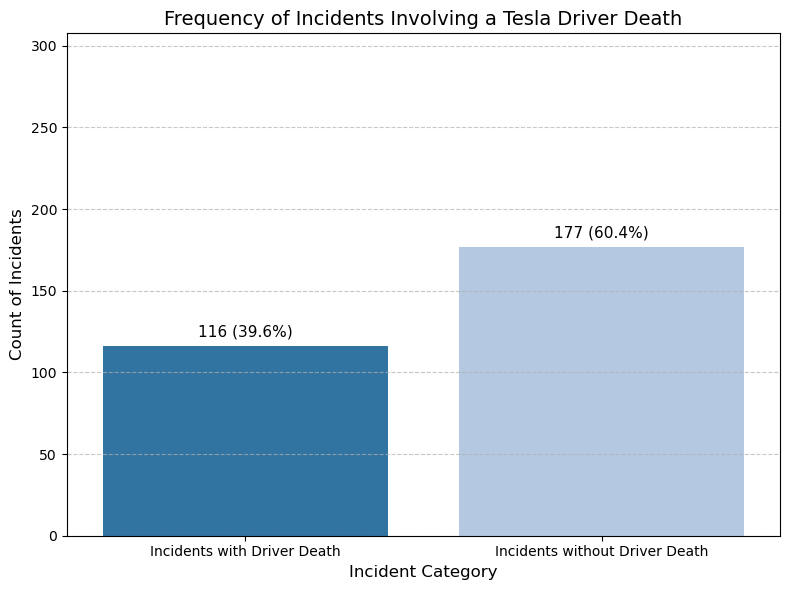

In [96]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'plot_data_driver' is already defined with columns 'Category' and 'Count'
# Data based on previous calculation:
# Incidents with Driver Death: 116
# Incidents without Driver Death: 177
total_incidents = 293 

plt.figure(figsize=(8, 6))

ax = sns.barplot(
    x='Category', 
    y='Count', 
    data=plot_data_driver, 
    palette=['#1f77b4', '#aec7e8']
)

# Add annotations (Count and Percentage)
for p in ax.patches:
    height = p.get_height()
    percentage = (height / total_incidents) * 100
    ax.annotate(f'{int(height)} ({percentage:.1f}%)', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='center', 
                xytext=(0, 10), 
                textcoords='offset points',
                fontsize=11)

plt.title('Frequency of Incidents Involving a Tesla Driver Death', fontsize=14)
plt.xlabel('Incident Category', fontsize=12)
plt.ylabel('Count of Incidents', fontsize=12)
plt.xticks(rotation=0)
plt.ylim(0, total_incidents * 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 10. Victim Category Analysis
The following cells break down fatalities by the role of the victim to understand who is most at risk:
1.  **Tesla Driver:** Frequency of incidents where the driver was killed.
2.  **Tesla Occupant:** Frequency of incidents involving passengers.
3.  **Other Vehicle:** Incidents involving fatalities in cars other than the Tesla (collisions).
4.  **Vulnerable Road Users:** Incidents involving cyclists or pedestrians.

In [68]:
import pandas as pd
import numpy as np

# --- 1. Full Data Setup (Load, Filter, Clean) ---
df = pd.read_csv('Tesla-Deaths.csv', encoding='latin1')

def standardize_column_names(df):
    df.columns = df.columns.str.lower().str.replace(' ', '_', regex=True).str.replace(r'[^a-z0-9_]', '', regex=True)
    return df

df = standardize_column_names(df.copy())
df = df.iloc[1:295].copy() # Filter rows 2-295 (index 1 to 294)

# Clean and standardize the relevant deaths columns
deaths_col = '_deaths_'
occupant_col = '_tesla_occupant_'

# Clean all columns used for calculation
for col in [deaths_col, occupant_col]:
    df[col] = pd.to_numeric(df[col].astype(str).str.strip().replace('-', '0').replace('', '0'), errors='coerce').fillna(0).astype(int)

# Filter out the 92-death outlier row
df_cleaned = df[df[deaths_col] != 92].copy()

# --- 2. Calculate Non-Driver Occupant Death Proportion (Revised Task) ---

# Incidents where one or more NON-DRIVER occupants died
incidents_with_non_driver_death = (df_cleaned[occupant_col] > 0).sum()
total_incidents = len(df_cleaned)
total_non_driver_deaths = df_cleaned[occupant_col].sum()

# Calculate the proportion
proportion = (incidents_with_non_driver_death / total_incidents) * 100

print(f"Total Incidents Analyzed (excluding outlier): {total_incidents}")
print(f"Total Non-Driver Occupant Deaths: {total_non_driver_deaths}")
print(f"Total Incidents with 1+ Non-Driver Occupant Death: {incidents_with_non_driver_death}")
print(f"Proportion of events with 1+ Non-Driver Occupant Death: {proportion:.2f}%")

Total Incidents Analyzed (excluding outlier): 293
Total Non-Driver Occupant Deaths: 48
Total Incidents with 1+ Non-Driver Occupant Death: 43
Proportion of events with 1+ Non-Driver Occupant Death: 14.68%


/var/folders/0q/xf9ydzjn1g1963ctltkj0gjw0000gn/T/ipykernel_89989/2677818412.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


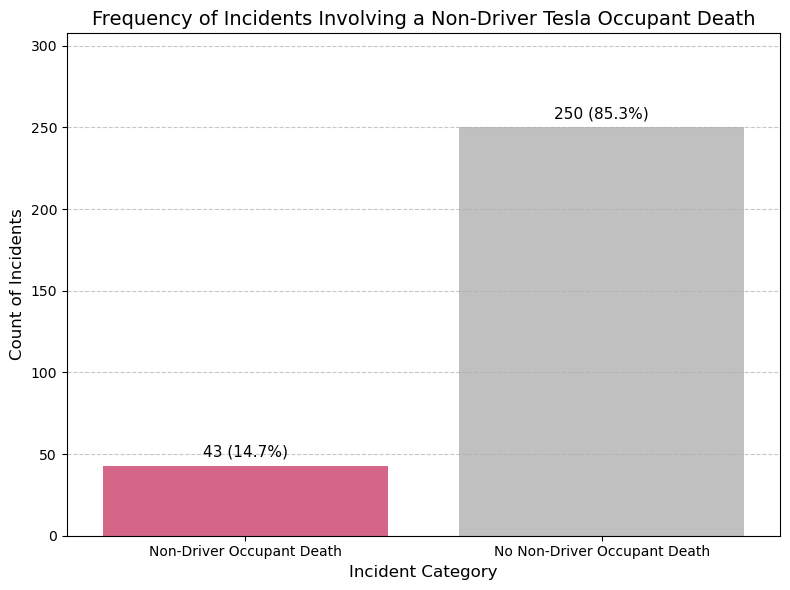

In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Full Data Setup (Load, Filter, Clean) ---
df = pd.read_csv('Tesla-Deaths.csv', encoding='latin1')

def standardize_column_names(df):
    df.columns = df.columns.str.lower().str.replace(' ', '_', regex=True).str.replace(r'[^a-z0-9_]', '', regex=True)
    return df

df = standardize_column_names(df.copy())
df = df.iloc[1:295].copy() # Filter rows 2-295 (index 1 to 294)

# Drop irrelevant columns 
cols_to_drop = ['_note_', '_deceased_1_', '_deceased_2_', '_deceased_3_', '_deceased_4_', 'unnamed_16', 'unnamed_17']
df.drop(columns=[col for col in cols_to_drop if col in df.columns], inplace=True, errors='ignore')

# Clean and standardize the deaths columns
deaths_col = '_deaths_'
occupant_col = '_tesla_occupant_'

# Clean all columns used for calculation
for col in [deaths_col, occupant_col]:
    df[col] = pd.to_numeric(df[col].astype(str).str.strip().replace('-', '0').replace('', '0'), errors='coerce').fillna(0).astype(int)

# Filter out the 92-death outlier row
df_cleaned = df[df[deaths_col] != 92].copy()

# --- 2. Calculate Incident Frequency (Data for Plot) ---
total_incidents = len(df_cleaned)
incidents_with_non_driver_death = (df_cleaned[occupant_col] > 0).sum()
incidents_without_non_driver_death = total_incidents - incidents_with_non_driver_death

# Prepare data for plotting the two categories with improved (shorter) labels
plot_data_occupant = pd.DataFrame({
    'Category': ['Non-Driver Occupant Death', 'No Non-Driver Occupant Death'], # Simplified Labels
    'Count': [incidents_with_non_driver_death, incidents_without_non_driver_death]
})

# --- 3. Plotting the Bar Chart with Cleaned X-Axis ---
plt.figure(figsize=(8, 6))

ax = sns.barplot(
    x='Category', 
    y='Count', 
    data=plot_data_occupant, 
    palette=['#e75480', '#c0c0c0']
)

# Add annotations to the bars for clarity
for p in ax.patches:
    height = p.get_height()
    percentage = (height / total_incidents) * 100
    ax.annotate(f'{int(height)} ({percentage:.1f}%)', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='center', 
                xytext=(0, 10), 
                textcoords='offset points',
                fontsize=11)

plt.title('Frequency of Incidents Involving a Non-Driver Tesla Occupant Death', fontsize=14)
plt.xlabel('Incident Category', fontsize=12)
plt.ylabel('Count of Incidents', fontsize=12)
# Removed rotation for shorter labels
plt.xticks(rotation=0) 
plt.ylim(0, total_incidents * 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('non_driver_occupant_death_frequency_bar_chart_clean_x.png')

### Frequency of Bicycle or Pedestrian Deaths

/var/folders/0q/xf9ydzjn1g1963ctltkj0gjw0000gn/T/ipykernel_89989/3866858829.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


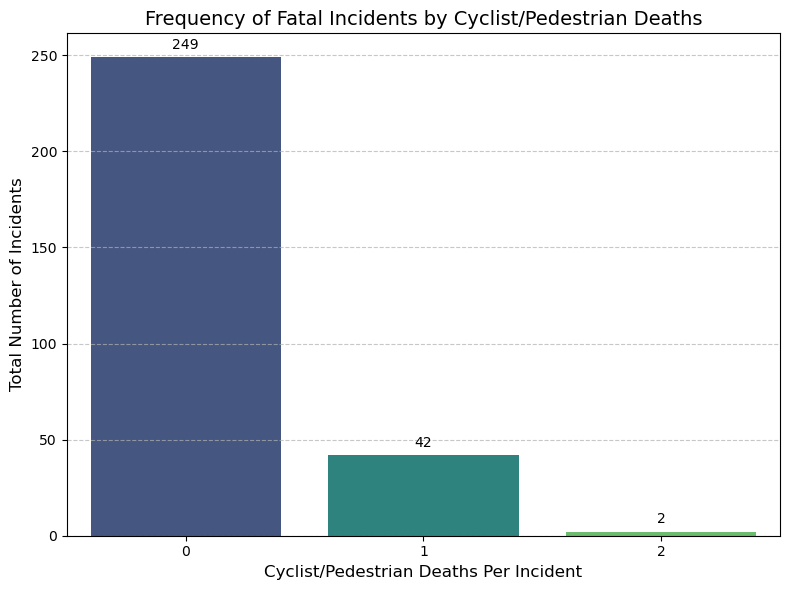

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Full Data Setup (Load, Filter, Clean) ---
df = pd.read_csv('Tesla-Deaths.csv', encoding='latin1')

def standardize_column_names(df):
    df.columns = df.columns.str.lower().str.replace(' ', '_', regex=True).str.replace(r'[^a-z0-9_]', '', regex=True)
    return df

df = standardize_column_names(df.copy())
df = df.iloc[1:295].copy() # Filter rows 2-295 (index 1 to 294)

# Clean and standardize the relevant deaths columns
deaths_col = '_deaths_'
cyclist_peds_col = '_cyclists_peds_'

# Clean all columns used for calculation
for col in [deaths_col, cyclist_peds_col]:
    df[col] = pd.to_numeric(df[col].astype(str).str.strip().replace('-', '0').replace('', '0'), errors='coerce').fillna(0).astype(int)

# Filter out the 92-death outlier row
df_cleaned = df[df[deaths_col] != 92].copy()

# --- 2. Calculate Distribution of Cyclist/Pedestrian Deaths (Data for Plot) ---

# Calculate the frequency distribution of cyclist/pedestrian fatalities per incident
cyclist_peds_distribution = df_cleaned[cyclist_peds_col].value_counts().reset_index(name='Total_Incidents')
cyclist_peds_distribution.columns = ['Cyclist/Ped_Deaths', 'Total_Incidents']
cyclist_peds_distribution = cyclist_peds_distribution.sort_values(by='Cyclist/Ped_Deaths', ascending=True)

# --- 3. Visualize the Distribution (Bar Chart) ---
plt.figure(figsize=(8, 6))

ax = sns.barplot(
    x='Cyclist/Ped_Deaths', 
    y='Total_Incidents', 
    data=cyclist_peds_distribution, 
    palette='viridis'
)

# Add annotations to the bars for clarity
for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontsize=10)

plt.title('Frequency of Fatal Incidents by Cyclist/Pedestrian Deaths', fontsize=14)
plt.xlabel('Cyclist/Pedestrian Deaths Per Incident', fontsize=12)
plt.ylabel('Total Number of Incidents', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('cyclist_peds_distribution.png')

### Frequency of Incidents Involving Tesla Drivers Or Passengers, Plus Cyclists & Pedestrians

In [75]:
import pandas as pd
import numpy as np

# --- 1. Full Data Setup (Load, Filter, Clean) ---
df = pd.read_csv('Tesla-Deaths.csv', encoding='latin1')

def standardize_column_names(df):
    df.columns = df.columns.str.lower().str.replace(' ', '_', regex=True).str.replace(r'[^a-z0-9_]', '', regex=True)
    return df

df = standardize_column_names(df.copy())
df = df.iloc[1:295].copy() # Filter rows 2-295 (index 1 to 294)

# Clean and standardize the relevant deaths columns, including the one requested
deaths_col = '_deaths_'
tsla_cycl_peds_col = '_tslacycl__peds_' # Corrected name for 'TSLA+cycl / peds'

# Clean all columns used for calculation
for col in [deaths_col, tsla_cycl_peds_col]:
    # Replace '-' with '0', then convert to integer count
    df[col] = pd.to_numeric(df[col].astype(str).str.strip().replace('-', '0').replace('', '0'), errors='coerce').fillna(0).astype(int)

# Filter out the 92-death outlier row
df_cleaned = df[df[deaths_col] != 92].copy()

# --- 2. Analyze Distribution of TSLA+cycl / peds (as requested) ---

# Calculate the frequency distribution of the requested column
tsla_cycl_peds_distribution = df_cleaned[tsla_cycl_peds_col].value_counts().reset_index(name='Total_Incidents')
tsla_cycl_peds_distribution.columns = ['Count_of_Deaths', 'Total_Incidents']
tsla_cycl_peds_distribution = tsla_cycl_peds_distribution.sort_values(by='Count_of_Deaths', ascending=True)

# Calculate the total number of recorded deaths in this column (to check the user's '61' figure)
total_deaths_in_col = df_cleaned[tsla_cycl_peds_col].sum()

print("--- Frequency of Tesla Driver/Occupant and Cyclist/Pedestrian Deaths per Incident ---")
print(tsla_cycl_peds_distribution.to_markdown(index=False))
print(f"\nTotal sum of deaths in the '{tsla_cycl_peds_col}' column: {total_deaths_in_col}")

--- Frequency of Tesla Driver/Occupant and Cyclist/Pedestrian Deaths per Incident ---
|   Count_of_Deaths |   Total_Incidents |
|------------------:|------------------:|
|                 0 |               113 |
|                 1 |               156 |
|                 2 |                20 |
|                 3 |                 3 |
|                 4 |                 1 |

Total sum of deaths in the '_tslacycl__peds_' column: 209


/var/folders/0q/xf9ydzjn1g1963ctltkj0gjw0000gn/T/ipykernel_89989/1360788937.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


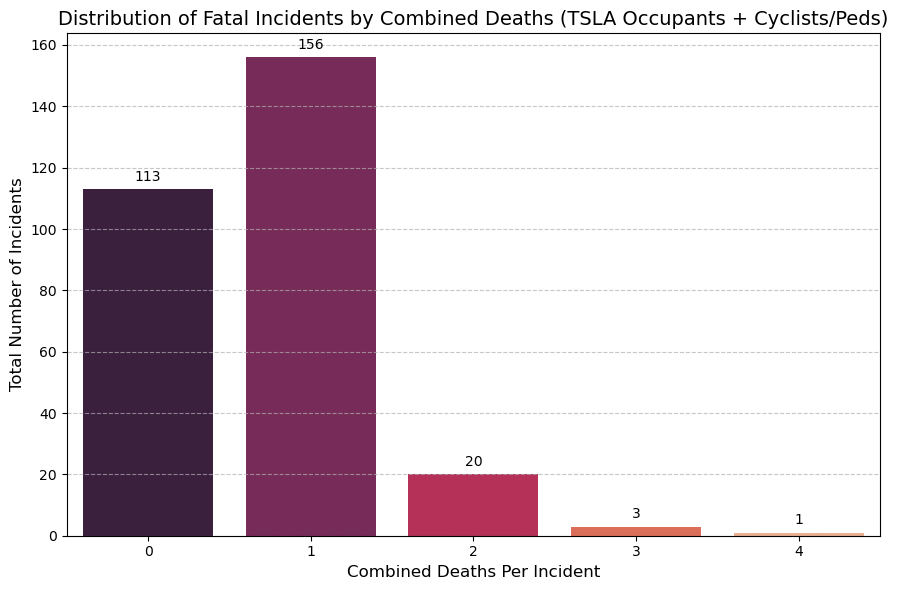

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Full Data Setup (Load, Filter, Clean) ---
df = pd.read_csv('Tesla-Deaths.csv', encoding='latin1')

def standardize_column_names(df):
    df.columns = df.columns.str.lower().str.replace(' ', '_', regex=True).str.replace(r'[^a-z0-9_]', '', regex=True)
    return df

df = standardize_column_names(df.copy())
df = df.iloc[1:295].copy() # Filter rows 2-295 (index 1 to 294)

# Define the correct columns
deaths_col = '_deaths_'
target_col = '_tslacycl__peds_'

# Clean all columns used for calculation
for col in [deaths_col, target_col]:
    df[col] = pd.to_numeric(df[col].astype(str).str.strip().replace('-', '0').replace('', '0'), errors='coerce').fillna(0).astype(int)

# Filter out the 92-death outlier row
df_cleaned = df[df[deaths_col] != 92].copy()

# --- 2. Calculate TSLA+cycl/peds Distribution ---
target_distribution = df_cleaned[target_col].value_counts().reset_index(name='Total_Incidents')
target_distribution.columns = ['TSLA+cycl/peds_Deaths', 'Total_Incidents']
target_distribution = target_distribution.sort_values(by='TSLA+cycl/peds_Deaths', ascending=True)

# --- 3. Visualize the Distribution (Bar Chart) ---
plt.figure(figsize=(9, 6))

ax = sns.barplot(
    x='TSLA+cycl/peds_Deaths', 
    y='Total_Incidents', 
    data=target_distribution, 
    palette='rocket'
)

# Add annotations to the bars for clarity
for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontsize=10)

plt.title('Distribution of Fatal Incidents by Combined Deaths (TSLA Occupants + Cyclists/Peds)', fontsize=14)
plt.xlabel('Combined Deaths Per Incident', fontsize=12)
plt.ylabel('Total Number of Incidents', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('tsla_cycl_peds_distribution.png')

### Frequency of Deaths In Other Vehicle (Not Tesla Driver or Passenger)

In [77]:
import pandas as pd
import numpy as np

# --- 1. Full Data Setup (Load, Filter, Clean) ---
df = pd.read_csv('Tesla-Deaths.csv', encoding='latin1')

def standardize_column_names(df):
    df.columns = df.columns.str.lower().str.replace(' ', '_', regex=True).str.replace(r'[^a-z0-9_]', '', regex=True)
    return df

df = standardize_column_names(df.copy())
df = df.iloc[1:295].copy() # Filter rows 2-295 (index 1 to 294)

# Define the correct columns
deaths_col = '_deaths_'
target_col = '_other_vehicle_'

# Clean all columns used for calculation
for col in [deaths_col, target_col]:
    # Replace '-', empty strings, and convert to integer
    df[col] = pd.to_numeric(df[col].astype(str).str.strip().replace('-', '0').replace('', '0'), errors='coerce').fillna(0).astype(int)

# Filter out the 92-death outlier row
df_cleaned = df[df[deaths_col] != 92].copy()

# --- 2. Calculate Frequency of Collisions with Other Vehicles ---

# Count incidents where deaths in other vehicles occurred (meaning a collision happened)
incidents_with_other_vehicle_death = (df_cleaned[target_col] > 0).sum()
total_incidents = len(df_cleaned)

# Calculate the frequency (proportion)
frequency_other_vehicle_collision = (incidents_with_other_vehicle_death / total_incidents) * 100

print(f"Total Incidents Analyzed (excluding outlier): {total_incidents}")
print(f"Total Incidents with Death(s) in Other Vehicle: {incidents_with_other_vehicle_death}")
print(f"Frequency of Incidents involving other vehicle deaths: {frequency_other_vehicle_collision:.2f}%")

Total Incidents Analyzed (excluding outlier): 293
Total Incidents with Death(s) in Other Vehicle: 110
Frequency of Incidents involving other vehicle deaths: 37.54%


/var/folders/0q/xf9ydzjn1g1963ctltkj0gjw0000gn/T/ipykernel_89989/2870889016.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


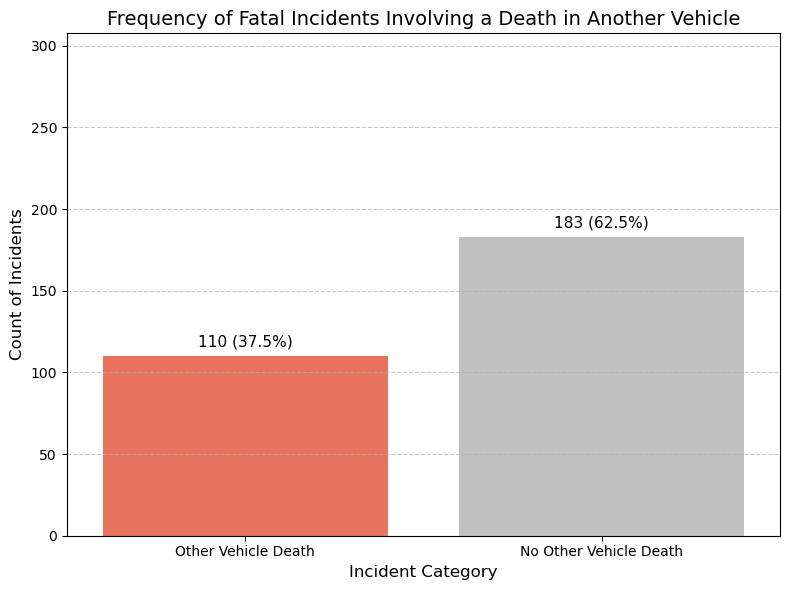

In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Full Data Setup (Load, Filter, Clean) ---
df = pd.read_csv('Tesla-Deaths.csv', encoding='latin1')

def standardize_column_names(df):
    df.columns = df.columns.str.lower().str.replace(' ', '_', regex=True).str.replace(r'[^a-z0-9_]', '', regex=True)
    return df

df = standardize_column_names(df.copy())
df = df.iloc[1:295].copy() # Filter rows 2-295 (index 1 to 294)

# Drop irrelevant columns 
cols_to_drop = ['_note_', '_deceased_1_', '_deceased_2_', '_deceased_3_', '_deceased_4_', 'unnamed_16', 'unnamed_17']
df.drop(columns=[col for col in cols_to_drop if col in df.columns], inplace=True, errors='ignore')

# Clean and standardize the deaths columns
deaths_col = '_deaths_'
target_col = '_other_vehicle_'

# Clean all columns used for calculation
for col in [deaths_col, target_col]:
    df[col] = pd.to_numeric(df[col].astype(str).str.strip().replace('-', '0').replace('', '0'), errors='coerce').fillna(0).astype(int)

# Filter out the 92-death outlier row
df_cleaned = df[df[deaths_col] != 92].copy()

# --- 2. Calculate Incident Frequency (Data for Plot) ---
total_incidents = len(df_cleaned)
incidents_with_other_vehicle_death = (df_cleaned[target_col] > 0).sum()
incidents_without_other_vehicle_death = total_incidents - incidents_with_other_vehicle_death

# Prepare data for plotting the two categories with simplified labels
plot_data_other_vehicle = pd.DataFrame({
    'Category': ['Other Vehicle Death', 'No Other Vehicle Death'],
    'Count': [incidents_with_other_vehicle_death, incidents_without_other_vehicle_death]
})

# --- 3. Plotting the Bar Chart ---
plt.figure(figsize=(8, 6))

ax = sns.barplot(
    x='Category', 
    y='Count', 
    data=plot_data_other_vehicle, 
    palette=['#ff6347', '#c0c0c0'] # Custom colors: Tomato Red (for other deaths) and Gray
)

# Add annotations to the bars for clarity (Count and Percentage)
for p in ax.patches:
    height = p.get_height()
    percentage = (height / total_incidents) * 100
    ax.annotate(f'{int(height)} ({percentage:.1f}%)', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='center', 
                xytext=(0, 10), 
                textcoords='offset points',
                fontsize=11)

plt.title('Frequency of Fatal Incidents Involving a Death in Another Vehicle', fontsize=14)
plt.xlabel('Incident Category', fontsize=12)
plt.ylabel('Count of Incidents', fontsize=12)
plt.ylim(0, total_incidents * 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('other_vehicle_death_frequency_bar_chart.png')

# 10. Victim Category Analysis
The following cells break down fatalities by the role of the victim to understand who is most at risk:
1.  **Tesla Driver:** Frequency of incidents where the driver was killed.
2.  **Tesla Occupant:** Frequency of incidents involving passengers.
3.  **Other Vehicle:** Incidents involving fatalities in cars other than the Tesla (collisions).
4.  **Vulnerable Road Users:** Incidents involving cyclists or pedestrians.

In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Rerunning full setup to ensure 'df' and 'model_clean' are available ---
df = pd.read_csv('Tesla-Deaths.csv', encoding='latin1')

def standardize_column_names(df):
    df.columns = df.columns.str.lower().str.replace(' ', '_', regex=True).str.replace(r'[^a-z0-9_]', '', regex=True)
    return df

df = standardize_column_names(df.copy())
df = df.iloc[1:295].copy() 

victim_cols = ['_tesla_driver_', '_tesla_occupant_', '_other_vehicle_', '_cyclists_peds_']
for col in victim_cols:
    df[col] = pd.to_numeric(df[col].astype(str).str.strip().replace('-', '0'), errors='coerce').fillna(0).astype(int)

def clean_model_name(model):
    model = str(model).strip().upper()
    model_map = {'3': 'MODEL 3', 'Y': 'MODEL Y', 'S': 'MODEL S', 'X': 'MODEL X'}
    return model_map.get(model, 'OTHER')
df['model_clean'] = df['_model_'].apply(clean_model_name)

# --- Plot Model Distribution ---
# Group by the clean model name and count incidents
incident_distribution_model = df.groupby('model_clean').size().reset_index(name='Total_Incidents').sort_values(by='Total_Incidents', ascending=False)

# --- Print the resulting table ---
print("--- Fatal Incidents Distribution by Tesla Model ---")
print(incident_distribution_model.to_markdown(index=False))

--- Fatal Incidents Distribution by Tesla Model ---
| model_clean   |   Total_Incidents |
|:--------------|------------------:|
| OTHER         |               183 |
| MODEL S       |                45 |
| MODEL 3       |                39 |
| MODEL X       |                17 |
| MODEL Y       |                10 |


/var/folders/0q/xf9ydzjn1g1963ctltkj0gjw0000gn/T/ipykernel_89989/1553611617.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='model_clean', y='Total_Incidents', data=incident_distribution_model, palette='rocket')


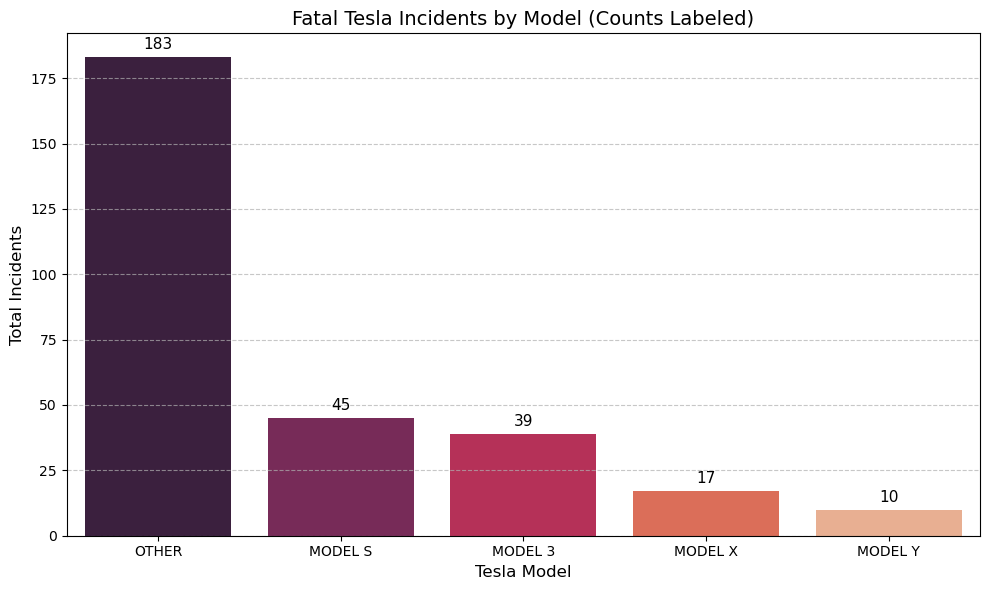

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Rerunning full setup to ensure 'df' and 'model_clean' are available ---
df = pd.read_csv('Tesla-Deaths.csv', encoding='latin1')

def standardize_column_names(df):
    df.columns = df.columns.str.lower().str.replace(' ', '_', regex=True).str.replace(r'[^a-z0-9_]', '', regex=True)
    return df

df = standardize_column_names(df.copy())
df = df.iloc[1:295].copy() 

# Drop irrelevant columns (needed for full cleanup, not strictly for this plot)
cols_to_drop = ['note', 'deceased_1', 'deceased_2', 'deceased_3', 'deceased_4', 'unnamed_16', 'unnamed_17']
df.drop(columns=[col for col in cols_to_drop if col in df.columns], inplace=True, errors='ignore')

victim_cols = ['_tesla_driver_', '_tesla_occupant_', '_other_vehicle_', '_cyclists_peds_']
for col in victim_cols:
    df[col] = pd.to_numeric(df[col].astype(str).str.strip().replace('-', '0'), errors='coerce').fillna(0).astype(int)

def clean_model_name(model):
    model = str(model).strip().upper()
    model_map = {'3': 'MODEL 3', 'Y': 'MODEL Y', 'S': 'MODEL S', 'X': 'MODEL X'}
    return model_map.get(model, 'OTHER')
df['model_clean'] = df['_model_'].apply(clean_model_name)

# --- Calculate Model Distribution ---
incident_distribution_model = df.groupby('model_clean').size().reset_index(name='Total_Incidents').sort_values(by='Total_Incidents', ascending=False)


# --- Plot Model Distribution with Annotations ---
plt.figure(figsize=(10, 6))
# Assign to ax to enable annotation
ax = sns.barplot(x='model_clean', y='Total_Incidents', data=incident_distribution_model, palette='rocket')

# CODE ADDED FOR DATA LABELS
for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontsize=11)

# Set labels and title
plt.title('Fatal Tesla Incidents by Model (Counts Labeled)', fontsize=14)
plt.xlabel('Tesla Model', fontsize=12)
plt.ylabel('Total Incidents', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('fatal_incidents_by_model_labeled.png')

### Frequency of Driver, Occupant, Cyclist/Pedestrian Deaths by Model

In [80]:
import pandas as pd
import numpy as np

# --- 1. Full Data Setup (Load, Filter, Clean) ---
df = pd.read_csv('Tesla-Deaths.csv', encoding='latin1')

def standardize_column_names(df):
    df.columns = df.columns.str.lower().str.replace(' ', '_', regex=True).str.replace(r'[^a-z0-9_]', '', regex=True)
    return df

df = standardize_column_names(df.copy())
df = df.iloc[1:295].copy() # Filter rows 2-295 (index 1 to 294)

# Define columns needed for cleaning
deaths_col = '_deaths_'
victim_cols = ['_tesla_driver_', '_tesla_occupant_', '_other_vehicle_', '_cyclists_peds_']

# Clean victim columns
for col in [deaths_col] + victim_cols:
    df[col] = pd.to_numeric(df[col].astype(str).str.strip().replace('-', '0').replace('', '0'), errors='coerce').fillna(0).astype(int)

# Filter out the 92-death outlier row
df_cleaned = df[df[deaths_col] != 92].copy()

# Clean Model Name
def clean_model_name(model):
    model = str(model).strip().upper()
    model_map = {'3': 'MODEL 3', 'Y': 'MODEL Y', 'S': 'MODEL S', 'X': 'MODEL X'}
    return model_map.get(model, 'OTHER')
df_cleaned['model_clean'] = df_cleaned['_model_'].apply(clean_model_name)

# --- 2. Analysis 1: Victim Distribution by Model (Count of Incidents with 1+ Death) ---

# Create binary flag columns for incidents with 1 or more death in the category
for col in victim_cols:
    df_cleaned[col + '_incident'] = (df_cleaned[col] > 0).astype(int)

# Group by model and sum the incident counts
victim_distribution = df_cleaned.groupby('model_clean')[[
    '_tesla_driver__incident',
    '_tesla_occupant__incident',
    '_other_vehicle__incident',
    '_cyclists_peds__incident'
]].sum().reset_index()

# Rename columns for presentation
victim_distribution.columns = [
    'Model',
    'Driver Death Incidents',
    'Occupant Death Incidents',
    'Other Vehicle Death Incidents',
    'Cyclist/Ped Death Incidents'
]

print("--- Incident Type Distribution by Model (Count of Incidents) ---")
print(victim_distribution.to_markdown(index=False))

--- Incident Type Distribution by Model (Count of Incidents) ---
| Model   |   Driver Death Incidents |   Occupant Death Incidents |   Other Vehicle Death Incidents |   Cyclist/Ped Death Incidents |
|:--------|-------------------------:|---------------------------:|--------------------------------:|------------------------------:|
| MODEL 3 |                       18 |                          6 |                              13 |                             6 |
| MODEL S |                       13 |                          9 |                              19 |                             5 |
| MODEL X |                        2 |                          3 |                               8 |                             4 |
| MODEL Y |                        1 |                          1 |                               8 |                             1 |
| OTHER   |                       82 |                         24 |                              62 |                            28

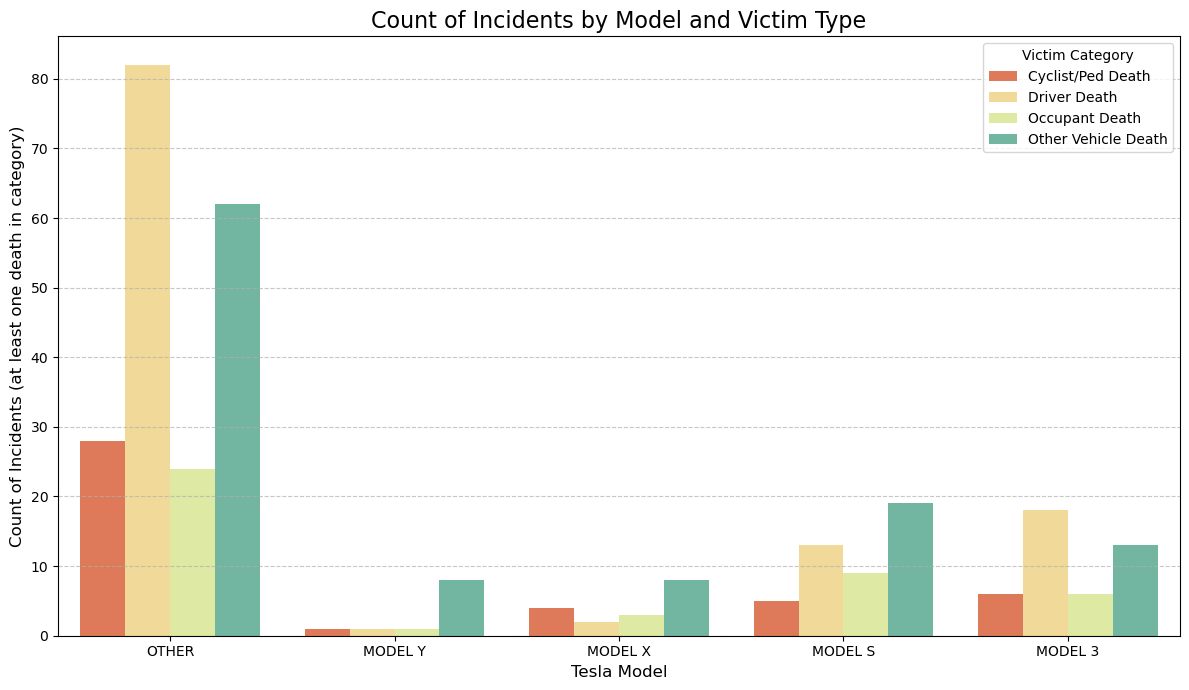

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Full Data Setup (Load, Filter, Clean) ---
df = pd.read_csv('Tesla-Deaths.csv', encoding='latin1')

def standardize_column_names(df):
    df.columns = df.columns.str.lower().str.replace(' ', '_', regex=True).str.replace(r'[^a-z0-9_]', '', regex=True)
    return df

df = standardize_column_names(df.copy())
df = df.iloc[1:295].copy() # Filter rows 2-295 (index 1 to 294)

# Define columns for cleaning and analysis
deaths_col = '_deaths_'
driver_col = '_tesla_driver_'
occupant_col = '_tesla_occupant_'
other_vehicle_col = '_other_vehicle_'
cyclist_peds_col = '_cyclists_peds_'

# Clean death columns
for col in [deaths_col, driver_col, occupant_col, other_vehicle_col, cyclist_peds_col]:
    df[col] = pd.to_numeric(df[col].astype(str).str.strip().replace('-', '0').replace('', '0'), errors='coerce').fillna(0).astype(int)

# Filter out the 92-death outlier row
df_cleaned = df[df[deaths_col] != 92].copy()

# Clean and categorize model names
def clean_model_name(model):
    model = str(model).strip().upper()
    model_map = {'3': 'MODEL 3', 'Y': 'MODEL Y', 'S': 'MODEL S', 'X': 'MODEL X'}
    return model_map.get(model, 'OTHER')
df_cleaned['model_clean'] = df_cleaned['_model_'].apply(clean_model_name)

# --- 2. Recalculate Analysis 1: Victim Distribution by Model ---
df_cleaned['Inc_Driver_Death'] = (df_cleaned[driver_col] > 0).astype(int)
df_cleaned['Inc_Occupant_Death'] = (df_cleaned[occupant_col] > 0).astype(int)
df_cleaned['Inc_Other_Vehicle_Death'] = (df_cleaned[other_vehicle_col] > 0).astype(int)
df_cleaned['Inc_Cyclist_Ped_Death'] = (df_cleaned[cyclist_peds_col] > 0).astype(int)

victim_distribution_by_model = df_cleaned.groupby('model_clean').agg(
    Total_Incidents=('model_clean', 'count'),
    Incidents_Driver_Death=('Inc_Driver_Death', 'sum'),
    Incidents_Occupant_Death=('Inc_Occupant_Death', 'sum'),
    Incidents_Other_Vehicle_Death=('Inc_Other_Vehicle_Death', 'sum'),
    Incidents_Cyclist_Ped_Death=('Inc_Cyclist_Ped_Death', 'sum')
).reset_index()

# Calculate proportion of incidents involving each victim type
prop_cols = ['Prop_Driver_Death', 'Prop_Occupant_Death', 'Prop_Other_Vehicle_Death', 'Prop_Cyclist_Ped_Death']
count_cols = ['Incidents_Driver_Death', 'Incidents_Occupant_Death', 'Incidents_Other_Vehicle_Death', 'Incidents_Cyclist_Ped_Death']
for count_col, prop_col in zip(count_cols, prop_cols):
    victim_distribution_by_model[prop_col] = (victim_distribution_by_model[count_col] / victim_distribution_by_model['Total_Incidents']) * 100

# --- 3. Plot 1: Victim Distribution (Normalized Stacked Bar Chart) ---

# Select model and proportion columns for plotting
plot_data_prop = victim_distribution_by_model[['model_clean'] + prop_cols].copy()

# Rename columns for cleaner legend
plot_data_prop.columns = ['Model', 'Driver Death Incident (%)', 'Occupant Death Incident (%)', 'Other Vehicle Death Incident (%)', 'Cyclist/Ped Death Incident (%)']

# Melt the DataFrame to long format for easier stacking
plot_data_long = plot_data_prop.melt(id_vars='Model', 
                                     var_name='Victim Type', 
                                     value_name='Proportion')

# Normalize the data: divide by total proportions (which should sum near 100 for each model)
# Plot the raw counts of incidents for each victim type using a grouped bar chart for comparison.

# Reshape the original count data for a grouped bar chart (Model vs. Count)
plot_data_counts = victim_distribution_by_model[['model_clean'] + count_cols].copy()
plot_data_counts.columns = ['Model', 'Driver Death', 'Occupant Death', 'Other Vehicle Death', 'Cyclist/Ped Death']

plot_data_long_counts = plot_data_counts.melt(id_vars='Model', 
                                              var_name='Victim Type', 
                                              value_name='Count of Incidents')

plt.figure(figsize=(12, 7))
ax = sns.barplot(
    x='Model', 
    y='Count of Incidents', 
    hue='Victim Type', 
    data=plot_data_long_counts.sort_values(by='Model', ascending=False), # Sort by Model for consistency
    palette='Spectral'
)

plt.title('Count of Incidents by Model and Victim Type', fontsize=16)
plt.xlabel('Tesla Model', fontsize=12)
plt.ylabel('Count of Incidents (at least one death in category)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Victim Category', loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('victim_distribution_by_model_grouped_bar_chart.png')

### Average Number of Fatalities per Model

In [81]:
import pandas as pd
import numpy as np

# --- 1. Full Data Setup (Load, Filter, Clean) ---
df = pd.read_csv('Tesla-Deaths.csv', encoding='latin1')

def standardize_column_names(df):
    df.columns = df.columns.str.lower().str.replace(' ', '_', regex=True).str.replace(r'[^a-z0-9_]', '', regex=True)
    return df

df = standardize_column_names(df.copy())
df = df.iloc[1:295].copy() # Filter rows 2-295 (index 1 to 294)

# Define columns for cleaning and analysis
deaths_col = '_deaths_'

# Clean death column
df[deaths_col] = pd.to_numeric(df[deaths_col].astype(str).str.strip().replace('-', '0').replace('', '0'), errors='coerce').fillna(0).astype(int)

# Filter out the 92-death outlier row
df_cleaned = df[df[deaths_col] != 92].copy()

# Clean and categorize model names
def clean_model_name(model):
    model = str(model).strip().upper()
    model_map = {'3': 'MODEL 3', 'Y': 'MODEL Y', 'S': 'MODEL S', 'X': 'MODEL X'}
    return model_map.get(model, 'OTHER')
df_cleaned['model_clean'] = df_cleaned['_model_'].apply(clean_model_name)

# --- 2. Analysis 2: Average Fatalities per Incident by Model ---

# Calculate the mean of the total deaths column grouped by model
avg_deaths_by_model = df_cleaned.groupby('model_clean')[deaths_col].mean().reset_index(name='Average_Deaths_Per_Incident')
avg_deaths_by_model = avg_deaths_by_model.sort_values(by='Average_Deaths_Per_Incident', ascending=False)

# Include total incidents count for context
incident_counts = df_cleaned.groupby('model_clean').size().reset_index(name='Total_Incidents')
avg_deaths_by_model = pd.merge(avg_deaths_by_model, incident_counts, on='model_clean').sort_values(by='Average_Deaths_Per_Incident', ascending=False)

print("--- Average Fatalities per Incident by Model ---")
print(avg_deaths_by_model[['model_clean', 'Total_Incidents', 'Average_Deaths_Per_Incident']].to_markdown(index=False))

--- Average Fatalities per Incident by Model ---
| model_clean   |   Total_Incidents |   Average_Deaths_Per_Incident |
|:--------------|------------------:|------------------------------:|
| MODEL Y       |                10 |                       1.3     |
| OTHER         |               182 |                       1.20879 |
| MODEL 3       |                39 |                       1.20513 |
| MODEL S       |                45 |                       1.17778 |
| MODEL X       |                17 |                       1.11765 |


/var/folders/0q/xf9ydzjn1g1963ctltkj0gjw0000gn/T/ipykernel_89989/2440667390.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


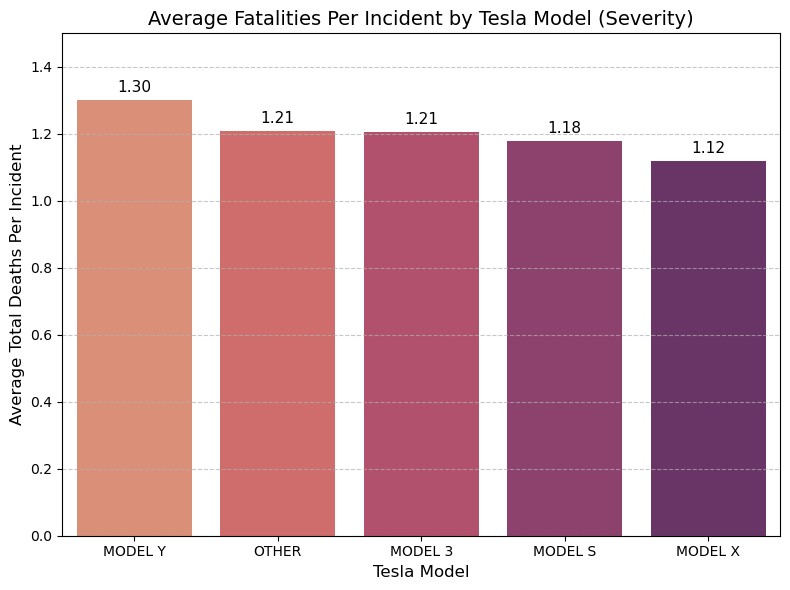

In [84]:
# --- 1. Recalculate Analysis 2: Average Fatalities per Incident by Model ---

# Define the deaths column name again for safety
deaths_col = '_deaths_'

# Group by model and calculate the mean of total deaths
average_fatalities_by_model = df_cleaned.groupby('model_clean')[deaths_col].mean().reset_index(name='Average_Deaths_Per_Incident')
average_fatalities_by_model = average_fatalities_by_model.sort_values(by='Average_Deaths_Per_Incident', ascending=False)

# --- 2. Plot 2: Average Fatalities (Bar Chart) ---

plt.figure(figsize=(8, 6))

ax = sns.barplot(
    x='model_clean', 
    y='Average_Deaths_Per_Incident', 
    data=average_fatalities_by_model, 
    palette='flare'
)

# Add annotations to the bars for clarity
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontsize=11)

plt.title('Average Fatalities Per Incident by Tesla Model (Severity)', fontsize=14)
plt.xlabel('Tesla Model', fontsize=12)
plt.ylabel('Average Total Deaths Per Incident', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0, 1.5) # Set a fixed y-limit for better comparison
plt.tight_layout()
plt.savefig('average_fatalities_by_model_bar_chart.png')

# 12. Autopilot Verification Analysis
Finally, we analyze the column `_verified_tesla_autopilot_deaths_` to calculate the proportion of total incidents where Autopilot engagement was officially verified. This provides insight into the prevalence of ADAS (Advanced Driver Assistance Systems) involvement in these fatal events.

In [6]:
import pandas as pd
import numpy as np

# --- 1. FULL DATA SETUP AND CLEANING (To prevent errors) ---
df = pd.read_csv('Tesla-Deaths.csv', encoding='latin1')

def standardize_column_names(df):
    df.columns = df.columns.str.lower().str.replace(' ', '_', regex=True).str.replace(r'[^a-z0-9_]', '', regex=True)
    return df

df = standardize_column_names(df.copy())
df = df.iloc[1:295].copy() # Filter rows 2-295 (index 1 to 294)

# Define death columns for robust cleaning
target_col = '_tesla_occupant_'
death_cols = ['_deaths_', target_col, '_tesla_driver_', '_other_vehicle_', 
              '_cyclists_peds_', '_verified_tesla_autopilot_deaths_']

# Robust Cleaning of Death Columns
for col in death_cols:
    df[col] = pd.to_numeric(
        df[col].astype(str).str.strip().replace('-', '0').replace('', '0'), 
        errors='coerce'
    ).fillna(0).astype(int)

# Filter out the 92-death outlier row and define the final cleaned DataFrame
df_cleaned = df[df['_deaths_'] != 92].copy()

# --- 2. MODEL CLEANING (Required for breakdown) ---
df_cleaned['_model_'] = df_cleaned['_model_'].astype(str).str.strip().str.upper().str.replace(r'[^A-Z0-9]', '', regex=True)
model_mapping = {
    'S': 'MODEL S',
    '3': 'MODEL 3',
    'X': 'MODEL X',
    'Y': 'MODEL Y'
}
def map_model(model):
    if model in model_mapping.keys():
        return model_mapping[model]
    elif model.startswith('S'): 
        return 'MODEL S'
    elif model == 'NAN' or model == '':
        return 'UNKNOWN'
    else:
        for k, v in model_mapping.items():
            if k in model:
                return v
        return 'UNKNOWN'

df_cleaned['clean_model'] = df_cleaned['_model_'].apply(map_model)

# --- 3. TASK 2b/2c: Calculate Total Non-Driver Tesla Occupant Deaths by Model ---

occupant_deaths_by_model = df_cleaned.groupby('clean_model')[target_col].sum().sort_values(ascending=False).reset_index()
occupant_deaths_by_model.columns = ['Model', 'Total Non-Driver Occupant Deaths']

print("--- Total Non-Driver Tesla Occupant Deaths by Model ---")
print(occupant_deaths_by_model.to_markdown(index=False))

--- Total Non-Driver Tesla Occupant Deaths by Model ---
| Model   |   Total Non-Driver Occupant Deaths |
|:--------|-----------------------------------:|
| UNKNOWN |                                 26 |
| MODEL S |                                 11 |
| MODEL 3 |                                  7 |
| MODEL X |                                  3 |
| MODEL Y |                                  1 |


--- Data used for Plot (Known Models) ---
| Model   |   Total Non-Driver Occupant Deaths |
|:--------|-----------------------------------:|
| MODEL S |                                 11 |
| MODEL 3 |                                  7 |
| MODEL X |                                  3 |
| MODEL Y |                                  1 |


/var/folders/0q/xf9ydzjn1g1963ctltkj0gjw0000gn/T/ipykernel_4602/1419995883.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


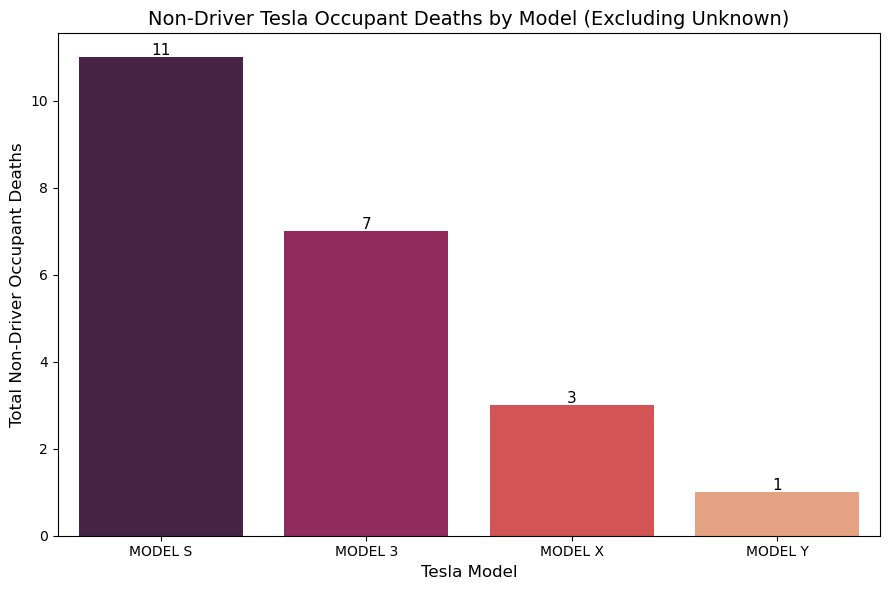

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- 1. FULL DATA SETUP AND CLEANING (To prevent errors) ---
df = pd.read_csv('Tesla-Deaths.csv', encoding='latin1')

def standardize_column_names(df):
    df.columns = df.columns.str.lower().str.replace(' ', '_', regex=True).str.replace(r'[^a-z0-9_]', '', regex=True)
    return df

df = standardize_column_names(df.copy())
df = df.iloc[1:295].copy() # Filter rows 2-295 (index 1 to 294)

# Define death columns for robust cleaning
target_col = '_tesla_occupant_'
death_cols = ['_deaths_', target_col, '_tesla_driver_', '_other_vehicle_', 
              '_cyclists_peds_', '_verified_tesla_autopilot_deaths_']

# Robust Cleaning of Death Columns
for col in death_cols:
    df[col] = pd.to_numeric(
        df[col].astype(str).str.strip().replace('-', '0').replace('', '0'), 
        errors='coerce'
    ).fillna(0).astype(int)

# Filter out the 92-death outlier row and define the final cleaned DataFrame
df_cleaned = df[df['_deaths_'] != 92].copy()

# --- 2. MODEL CLEANING (Required for Grouping) ---
# Clean the model column: Standardize known variations
df_cleaned['_model_'] = df_cleaned['_model_'].astype(str).str.strip().str.upper().str.replace(r'[^A-Z0-9]', '', regex=True)
model_mapping = {
    'S': 'MODEL S',
    '3': 'MODEL 3',
    'X': 'MODEL X',
    'Y': 'MODEL Y'
}
def map_model(model):
    if model in model_mapping.keys():
        return model_mapping[model]
    elif model.startswith('S'): 
        return 'MODEL S'
    elif model == 'NAN' or model == '':
        return 'UNKNOWN'
    else:
        for k, v in model_mapping.items():
            if k in model:
                return v
        return 'UNKNOWN'

df_cleaned['clean_model'] = df_cleaned['_model_'].apply(map_model)

# --- 3. TASK 2b/2c: Calculate Total Non-Driver Tesla Occupant Deaths by Model ---

occupant_deaths_by_model = df_cleaned.groupby('clean_model')[target_col].sum().reset_index()
occupant_deaths_by_model.columns = ['Model', 'Total Non-Driver Occupant Deaths']
occupant_deaths_by_model = occupant_deaths_by_model.sort_values('Total Non-Driver Occupant Deaths', ascending=False)

# Filter out UNKNOWN for better visualization of known models
plot_data = occupant_deaths_by_model[occupant_deaths_by_model['Model'] != 'UNKNOWN'].copy()

# --- Plotting Bar Chart ---
plt.figure(figsize=(9, 6))
ax = sns.barplot(
    x='Model', 
    y='Total Non-Driver Occupant Deaths', 
    data=plot_data, 
    palette='rocket'
)

# Add annotations to the bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='center', 
                xytext=(0, 5), 
                textcoords='offset points',
                fontsize=11)

plt.title('Non-Driver Tesla Occupant Deaths by Model (Excluding Unknown)', fontsize=14)
plt.xlabel('Tesla Model', fontsize=12)
plt.ylabel('Total Non-Driver Occupant Deaths', fontsize=12)
plt.tight_layout()
plt.savefig('non_driver_occupant_deaths_by_model_bar_chart.png')

print("--- Data used for Plot (Known Models) ---")
print(plot_data.to_markdown(index=False))

In [85]:
import pandas as pd
import numpy as np

# --- 1. Full Data Setup (Load, Filter, Clean) ---
df = pd.read_csv('Tesla-Deaths.csv', encoding='latin1')

def standardize_column_names(df):
    df.columns = df.columns.str.lower().str.replace(' ', '_', regex=True).str.replace(r'[^a-z0-9_]', '', regex=True)
    return df

df = standardize_column_names(df.copy())
df = df.iloc[1:295].copy() # Filter rows 2-295 (index 1 to 294)

# Define columns for cleaning and analysis
deaths_col = '_deaths_'
target_col = '_verified_tesla_autopilot_deaths_'

# Clean death columns
for col in [deaths_col, target_col]:
    # Replace '-', empty strings, and convert to integer
    df[col] = pd.to_numeric(df[col].astype(str).str.strip().replace('-', '0').replace('', '0'), errors='coerce').fillna(0).astype(int)

# Filter out the 92-death outlier row
df_cleaned = df[df[deaths_col] != 92].copy()

# --- 2. Analyze Verified Tesla Autopilot Deaths ---

# Total number of incidents with at least one verified Autopilot death
incidents_with_autopilot_death = (df_cleaned[target_col] > 0).sum()

# Total number of verified Autopilot deaths
total_autopilot_deaths = df_cleaned[target_col].sum()

# Calculate the proportion of total incidents that involve verified Autopilot deaths
total_incidents = len(df_cleaned)
proportion_of_incidents = (incidents_with_autopilot_death / total_incidents) * 100

print(f"Total Incidents Analyzed: {total_incidents}")
print(f"Total Incidents with Verified Autopilot Death: {incidents_with_autopilot_death}")
print(f"Proportion of Incidents with Verified Autopilot Death: {proportion_of_incidents:.2f}%")
print(f"Total Verified Autopilot Deaths: {total_autopilot_deaths}")

Total Incidents Analyzed: 293
Total Incidents with Verified Autopilot Death: 16
Proportion of Incidents with Verified Autopilot Death: 5.46%
Total Verified Autopilot Deaths: 19


/var/folders/0q/xf9ydzjn1g1963ctltkj0gjw0000gn/T/ipykernel_89989/76633986.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


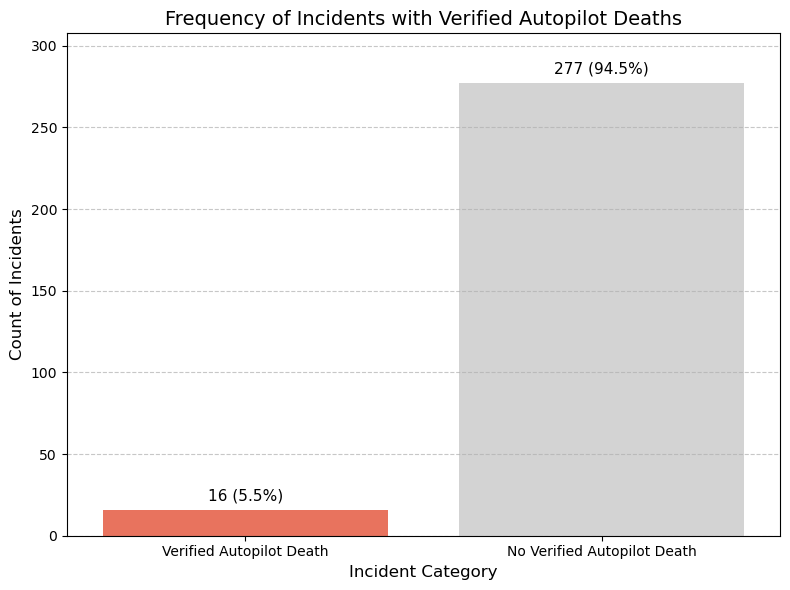

In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Full Data Setup (Load, Filter, Clean) ---
df = pd.read_csv('Tesla-Deaths.csv', encoding='latin1')

def standardize_column_names(df):
    df.columns = df.columns.str.lower().str.replace(' ', '_', regex=True).str.replace(r'[^a-z0-9_]', '', regex=True)
    return df

df = standardize_column_names(df.copy())
df = df.iloc[1:295].copy() # Filter rows 2-295 (index 1 to 294)

# Define columns for cleaning and analysis
deaths_col = '_deaths_'
target_col = '_verified_tesla_autopilot_deaths_'

# Clean death columns
for col in [deaths_col, target_col]:
    df[col] = pd.to_numeric(df[col].astype(str).str.strip().replace('-', '0').replace('', '0'), errors='coerce').fillna(0).astype(int)

# Filter out the 92-death outlier row
df_cleaned = df[df[deaths_col] != 92].copy()

# --- 2. Calculate Incident Frequency (Data for Plot) ---
incidents_with_ap_deaths = (df_cleaned[target_col] > 0).sum()
total_incidents = len(df_cleaned)
incidents_without_ap_deaths = total_incidents - incidents_with_ap_deaths

# Prepare data for plotting the two categories with simplified labels
plot_data_ap = pd.DataFrame({
    'Category': ['Verified Autopilot Death', 'No Verified Autopilot Death'],
    'Count': [incidents_with_ap_deaths, incidents_without_ap_deaths]
})

# --- 3. Plotting the Bar Chart (The superior choice) ---
plt.figure(figsize=(8, 6))

ax = sns.barplot(
    x='Category', 
    y='Count', 
    data=plot_data_ap, 
    palette=['#FF6347', '#D3D3D3'] # Red (for AP) and Light Gray
)

# Add annotations to the bars for clarity (Count and Percentage)
for p in ax.patches:
    height = p.get_height()
    percentage = (height / total_incidents) * 100
    ax.annotate(f'{int(height)} ({percentage:.1f}%)', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='center', 
                xytext=(0, 10), 
                textcoords='offset points',
                fontsize=11)

plt.title('Frequency of Incidents with Verified Autopilot Deaths', fontsize=14)
plt.xlabel('Incident Category', fontsize=12)
plt.ylabel('Count of Incidents', fontsize=12)
plt.ylim(0, total_incidents * 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('verified_autopilot_incident_frequency_bar_chart.png')